# Quantum Graphs as Toy Models
## Phantom eigenmode fabrication: exact derivations
*Working Document — April 2026 · Part of the Phantom Eigenmode / Compression–Commutator Geometry series*

---

## Preface: Why Quantum Graphs

The phantom eigenmode framework — phantom fabrication from measurement gaps, the decomposition $w_{G,N}=w_G+s_{G,N}$, the three-part anatomy of bulk/edge/projector — needs concrete toy models where everything can be computed exactly and inspected in closed form. Quantum graphs provide those models.

A quantum graph is a metric graph equipped with a differential operator (here: $-d^2/dx^2$ on each edge) and matching conditions at vertices. It is lower-dimensional than a 2D membrane but richer than a 1D interval because it has topology — the graph structure — as an additional geometric variable. Crucially, every object in the phantom framework has an explicit formula on a quantum graph: eigenfunctions are trigonometric, coupling matrices are elementary integrals, the mask-adapted basis is computed by $2\times 2$ linear algebra, and the scattering sources are delta functions at two points.

On the disk or rectangle, the same calculations require Bessel functions, quadrature, and numerical eigenvalue problems. On the star graph everything is analytic. This is why the star graph result — one direction with $\beta_1=(2/3)\rho$, the orthogonal direction with $\beta_2=0$ exactly — is the clearest illustration in the entire project of what the mask-adapted basis physically means.

This document develops four graph examples in increasing order of complexity: (1) the path graph (1D interval, simplest case), (2) the equilateral 3-edge star (the main toy model), (3) the $k$-edge equilateral star (general formula), (4) two gaps on the star (multi-gap synthesis made explicit). A final section works the scattering picture on graphs and shows why T6 (boundary-layer localization) is provable there when it remains open in 2D.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f8f6',
    'grid.color': 'white', 'grid.linewidth': 1.2,
})
np.random.seed(42)

BLUE  = '#1a5fa8'; AMBER = '#b85c00'; GREEN = '#2a8c3a'
RED   = '#cc2222'; PURP  = '#8844aa'; TEAL  = '#1a8c8c'

def bt(ax, x, y, txt, zorder=6, **kw):
    kw.setdefault('fontweight', 'heavy')
    kw.setdefault('color', 'black')
    kw.setdefault('fontsize', 10)
    t = ax.text(x, y, txt, zorder=zorder, **kw)
    t.set_path_effects([pe.withStroke(linewidth=3, foreground='white')])
    return t

# ── Core star-graph functions ────────────────────────────────────────────────
def rho_p(p, a, b, ell=1.0):
    """Radial overlap: missing mass fraction on [a,b] for antisymmetric mode p."""
    return ((b-a)/ell
            - (np.sin(2*p*np.pi*b/ell) - np.sin(2*p*np.pi*a/ell)) / (2*p*np.pi))

def rho_pq(p, q, a, b, ell=1.0):
    """Cross-overlap between antisymmetric modes p and q on gap [a,b]."""
    if p == q:
        return rho_p(p, a, b, ell)
    dm, sm = p - q, p + q
    t1 = (np.sin(dm*np.pi*b/ell) - np.sin(dm*np.pi*a/ell)) / (dm*np.pi)
    t2 = (np.sin(sm*np.pi*b/ell) - np.sin(sm*np.pi*a/ell)) / (sm*np.pi)
    return t1 - t2

def beta1(p, a, b, k=3, ell=1.0):
    """β₁ = ((k-1)/k) ρ_p — the nonzero exposure eigenvalue."""
    return ((k-1)/k) * rho_p(p, a, b, ell)

def sym_eigenfunction(q, x, k=3, ell=1.0):
    """Symmetric eigenfunction on each edge: √(2/kℓ) cos(k_q x)."""
    kq = (q + 0.5) * np.pi / ell
    return np.sqrt(2/(k*ell)) * np.cos(kq * x)

def antisym_eigenfunction(p, alpha, x, ell=1.0):
    """Antisymmetric eigenfunction on edge j: √(2/ℓ) α_j sin(pπx/ℓ)."""
    return np.sqrt(2/ell) * alpha * np.sin(p * np.pi * x / ell)

# Standard basis vectors for 3-edge star
alpha1 = np.array([1, -1,  0]) / np.sqrt(2)   # ψ^(1)
alpha2 = np.array([1,  1, -2]) / np.sqrt(6)   # ψ^(2)

# Mask-adapted basis
u1_coeff = np.array([2, -1, -1]) / np.sqrt(6)  # visits e₁
u2_coeff = np.array([0,  1, -1]) / np.sqrt(2)  # avoids e₁

print("Imports OK")
print(f"u₁·u₂ = {np.dot(u1_coeff, u2_coeff):.6f}  (should be 0)")
print(f"||u₁|| = {np.linalg.norm(u1_coeff):.6f}, ||u₂|| = {np.linalg.norm(u2_coeff):.6f}")


Imports OK
u₁·u₂ = 0.000000  (should be 0)
||u₁|| = 1.000000, ||u₂|| = 1.000000


---
## Part I — The Path Graph

### 1.1 Setup

The simplest quantum graph: a single edge (a 1D interval) of length $L$ with Dirichlet boundary conditions at both ends. This is identical to the 1D Dirichlet Laplacian on $[0,L]$.

Eigenfunctions: $\varphi_n(x)=\sqrt{2/L}\sin(n\pi x/L)$, $n=1,2,3,\ldots$, $\lambda_n=(n\pi/L)^2$.

Spectrum: simple (eigenvalues $\lambda_n = (n\pi/L)^2$ are distinct for every $L > 0$; no genericity is needed). This graph has no degenerate eigenspaces, so the phantom analysis reduces entirely to the simple-spectrum case.

### 1.2 The Coupling Matrix

Gap $G=[a,b]\subset[0,L]$. The coupling matrix entries are:
$$K_{mn} = \int_a^b\varphi_m(x)\varphi_n(x)\,dx = \frac{2}{L}\int_a^b\sin\frac{m\pi x}{L}\sin\frac{n\pi x}{L}\,dx.$$

Using the product-to-sum identity $\sin A\sin B=\frac{1}{2}[\cos(A-B)-\cos(A+B)]$:
$$K_{mn} = \frac{\sin((m-n)\pi b/L)-\sin((m-n)\pi a/L)}{(m-n)\pi} - \frac{\sin((m+n)\pi b/L)-\sin((m+n)\pi a/L)}{(m+n)\pi} \quad(m\neq n).$$

Diagonal (missing mass fraction):
$$K_{nn} = a_n = \frac{b-a}{L} - \frac{\sin(2n\pi b/L)-\sin(2n\pi a/L)}{2n\pi}.$$

This is the exact sinc-like coupling. For $m-n$ large: $K_{mn}\sim 1/(m-n)\pi$ — slow algebraic decay because the hard gap edges create a step-function discontinuity in the mask, which produces sinc-type Fourier coefficients.

### 1.3 The Boundary Wronskian on the Path Graph

$$(\lambda_m-\lambda_n)K_{mn} = [W_{mn}(b)-W_{mn}(a)],$$

where the Wronskian of $\varphi_n$ and $\varphi_m$ is:
$$W_{mn}(x) = \varphi_m(x)\varphi_n'(x)-\varphi_n(x)\varphi_m'(x) = \frac{2}{L}\left[\frac{n\pi}{L}\sin\frac{m\pi x}{L}\cos\frac{n\pi x}{L} - \frac{m\pi}{L}\sin\frac{n\pi x}{L}\cos\frac{m\pi x}{L}\right].$$

This is an explicit formula with no approximation. The coupling between modes $m$ and $n$ is exactly the difference of Wronskian values at the two gap endpoints, divided by the eigenvalue gap $(m\pi/L)^2-(n\pi/L)^2$.

Near-resonant modes ($m\approx n$): the denominator is small, so even moderate Wronskian values give large coupling. The phantom energy is not spectrally flat — it concentrates near the source mode's eigenvalue neighbors.

Gap endpoint alignment: if $a$ or $b$ coincides with a nodal point of $\varphi_n$, then $W_{mn}(x)$ at that point involves $\varphi_n(x)=0$, suppressing that endpoint's contribution. Placing gap endpoints at nodal points of the source mode reduces the inter-eigenvalue coupling.

### 1.4 The Three Spatial Objects on the Path Graph

For source $f=c\,\varphi_{n_0}$ (single mode, simple spectrum):

**Exact modal lie:** $w_G(x)=a_{n_0}\cdot\varphi_{n_0}(x)$ for $x\notin[a,b]$. Spatially uniform outside the gap.

**Commutator correction:**
$$s_{G,N}(x) = -\frac{c}{2L}\int_a^b \bigl[D_N(x-y) - D_N(x+y)\bigr]\sin\frac{n_0\pi y}{L}\,dy,$$

where $D_N(t)=\sin((N+\frac{1}{2})\pi t/L)/\sin(\pi t/2L)$ is the $2L$-periodic Dirichlet kernel, and $\Pi_N(x,y) = \tfrac{1}{2L}[D_N(x-y)-D_N(x+y)]$ is the exact spectral projector kernel on $[0,L]$ with Dirichlet BCs at both ends. The $D_N(x+y)$ term is the Dirichlet image at $x=0$; it is bounded by $L/(x+y)$ (with an $O(1)$ constant per §1.5) and is significant only when $x$ is close to the vertex at $x=0$.

The finite-band phantom field is $w_{G,N}=w_G+s_{G,N}$. Near $x=a$ and $x=b$: large Dirichlet-kernel oscillations. Away from the gap: the correction $s_{G,N}$ decays and $w_{G,N}\to a_{n_0}\varphi_{n_0}(x)$.

### 1.5 T6 Proved on the Path Graph

The boundary-layer localization theorem (T6) is provable on the path graph because the Dirichlet-interval reproducing kernel has explicit decay. Writing $K_N(x,y)=(2/L)\sum_{n=1}^N\sin(n\pi x/L)\sin(n\pi y/L) = (1/L)[D_N(|x-y|/L) - D_N((x+y)/L)]$ with $D_N(s)=\sum_{n=1}^N\cos(n\pi s)$, a direct summation gives $D_N(s) = \frac{\sin((N+1/2)\pi s)}{2\sin(\pi s/2)} - \frac{1}{2}$, and hence
$$|D_N(s)|\leq\frac{1}{2|\sin(\pi s/2)|}+\frac{1}{2}\leq\frac{1}{|\sin(\pi s/2)|}\leq\frac{1}{|s|}\qquad\text{for }0<|s|<1,$$
using $|\sin(u)|\geq(2/\pi)|u|$ for $|u|\leq\pi/2$. With $s=t/L$: $|D_N(t/L)|\leq L/|t|$ for $0<|t|<L$.

Therefore for $x$ outside the gap with $|x-a|>L/(2N)$ and $|x-b|>L/(2N)$, up to a fixed constant $C>0$:
$$|s_{G,N}(x)|\leq\frac{C|c|(b-a)}{L}\left[\frac{1}{\min(|x-a|,|x-b|)}+\frac{1}{x+a}\right].$$

The first term is the direct decay away from the gap endpoints; the second is the image contribution, which is additionally bounded by $1/(x+a)$ and is negligible when $x\gg L/N$ away from the vertex $x=0$.

The correction decays as $1/$(distance to nearest gap endpoint). The boundary layer has width $O(L/N)=O(\lambda_N^{-1/2})$ around the endpoints $a$ and $b$. This is the explicit 1D proof of T6. The general 2D version requires Hörmander's spectral function estimates for $\Pi_N(x,y)$ — that is where the problem remains open.

---
## Part II — The Equilateral 3-Edge Star: Setup

### 2.1 Graph Structure

Three edges $e_1,e_2,e_3$, each of length $\ell$, meeting at a central vertex $v_0$. On each edge $e_j$, use coordinate $x\in[0,\ell]$ with $x=0$ at the central vertex $v_0$ and $x=\ell$ at the leaf vertex $v_j$.

The differential operator on each edge is $L=-d^2/dx^2$. The domain is defined by two conditions:
- Dirichlet boundary conditions at the three leaves: $\psi_j(\ell)=0$ for $j=1,2,3$.
- Kirchhoff (natural) conditions at the central vertex: continuity $\psi_1(0)=\psi_2(0)=\psi_3(0)$, and flux balance $\psi_1'(0)+\psi_2'(0)+\psi_3'(0)=0$, where primes denote outward derivatives (positive $x$ direction at $v_0$).

The self-adjoint operator $L$ with these conditions has a complete orthonormal eigenbasis on $L^2(e_1\cup e_2\cup e_3)=L^2([0,\ell])^3$. There are exactly two spectral families.

### 2.2 The Symmetric (Simple Spectrum) Family

**Ansatz:** same function on all three edges, $\psi_j(x)=A\cos(kx)$.

Dirichlet at $x=\ell$: $A\cos(k\ell)=0\Rightarrow\cos(k\ell)=0\Rightarrow k_q=(q+\frac{1}{2})\pi/\ell$, $q=0,1,2,\ldots$

Flux balance at $x=0$: $\psi_j'(0)=-kA\sin(0)=0$, sum $=0$. ✓

Normalization: $(3A^2\ell/2)=1\Rightarrow A=\sqrt{2/3\ell}$.

$$\varphi^{(s)}_q(x\text{ on }e_j) = \sqrt{\frac{2}{3\ell}}\cos(k_q x), \quad k_q=\frac{(q+\frac{1}{2})\pi}{\ell}, \quad \lambda^{(s)}_q=k_q^2=\left(\frac{(q+\frac{1}{2})\pi}{\ell}\right)^2, \quad q=0,1,2,\ldots$$

All eigenvalues distinct (simple spectrum for any $\ell$). These modes look the same on all three edges. A measurement gap on $e_1$ sees exactly the same function as on $e_2$ or $e_3$.

### 2.3 Kirchhoff Condition Derivation for Symmetric Modes

It is worth pausing to verify that the flux condition works. At $x=0$ on edge $e_j$, the outward direction is $+x$. The derivative of $\psi_j(x)=A\cos(k_q x)$ at $x=0$ is:
$$\psi_j'(0) = -Ak_q\sin(0) = 0.$$

The flux balance requires $\psi_1'(0)+\psi_2'(0)+\psi_3'(0)=0+0+0=0$. ✓ The cosine family satisfies the Kirchhoff condition for free because $\sin(0)=0$.

This would not work for a sine ansatz. Try $\psi_j(x)=B\sin(kx)$: gives $\psi_j'(0)=Bk$, flux: $3Bk\neq 0$ unless $B=0$. So the pure sine-on-all-edges ansatz fails. The antisymmetric family (next section) requires the edges to cancel each other's fluxes.

### 2.4 The Antisymmetric (Degenerate) Family

**Ansatz:** $\psi_j(x)=\alpha_j\sin(kx)$ on edge $e_j$, with $\alpha_j\in\mathbb{R}$.

Dirichlet at $x=\ell$: $\alpha_j\sin(k\ell)=0\Rightarrow\sin(k\ell)=0\Rightarrow k_p=p\pi/\ell$, $p=1,2,3,\ldots$

Continuity at $x=0$: $\alpha_j\sin(0)=0$ for all $j$. ✓ (Automatically satisfied — all edges meet at zero, and $\sin(0)=0$ regardless of $\alpha_j$.)

Flux balance at $x=0$: $\sum_j\alpha_j k_p\cos(0)=k_p\sum_j\alpha_j=0\Rightarrow\sum_j\alpha_j=0$.

The constraint $\sum_j\alpha_j=0$ defines a **2-dimensional subspace** of $\mathbb{R}^3$. This is why the antisymmetric eigenspaces are 2-dimensional — the Kirchhoff flux condition cuts the free parameter space from 3D to 2D.

**Convention:** define the eigenfunction as $\psi^{(i)}_p(x\text{ on }e_j)=\sqrt{2/\ell}\,\alpha^{(i)}_j\sin(p\pi x/\ell)$, where $\alpha^{(i)}$ is a unit vector in $\mathbb{R}^3$ with $\sum_j\alpha^{(i)}_j=0$. Then:
$$\int_0^\ell|\psi^{(i)}_p(x\text{ on }e_j)|^2\,dx = (\alpha^{(i)}_j)^2.$$

Total $L^2$ norm: $\sum_j(\alpha^{(i)}_j)^2=\|\alpha^{(i)}\|^2=1$. ✓

**Antisymmetric eigenfunctions:**
$$\psi^{(i)}_p(x\text{ on }e_j) = \sqrt{\frac{2}{\ell}}\,\alpha^{(i)}_j\sin\frac{p\pi x}{\ell}, \quad \lambda^{(a)}_p=\left(\frac{p\pi}{\ell}\right)^2, \quad p=1,2,3,\ldots$$

Choose orthonormal basis: $\alpha^{(1)}=(1,-1,0)/\sqrt{2}$, $\alpha^{(2)}=(1,1,-2)/\sqrt{6}$.

**Verification:** $\langle\alpha^{(1)},\alpha^{(2)}\rangle=(1\cdot 1+(-1)\cdot 1+0\cdot(-2))/\sqrt{12}=0$ ✓. Constraint: $1-1+0=0$ ✓ and $1+1-2=0$ ✓.

Note that the antisymmetric eigenvalues $\lambda^{(a)}_p=(p\pi/\ell)^2$ coincide exactly with those of a single Dirichlet interval $[0,\ell]$ — the graph just makes each eigenvalue multiplicity 2 instead of 1.

### 2.5 Spectral Interleaving

The full spectrum consists of the symmetric family $\lambda^{(s)}_q=((q+\frac{1}{2})\pi/\ell)^2$ and the antisymmetric family $\lambda^{(a)}_p=(p\pi/\ell)^2$. The symmetric and antisymmetric families interleave. Symmetric eigenvalues are simple; antisymmetric eigenvalues have multiplicity 2.


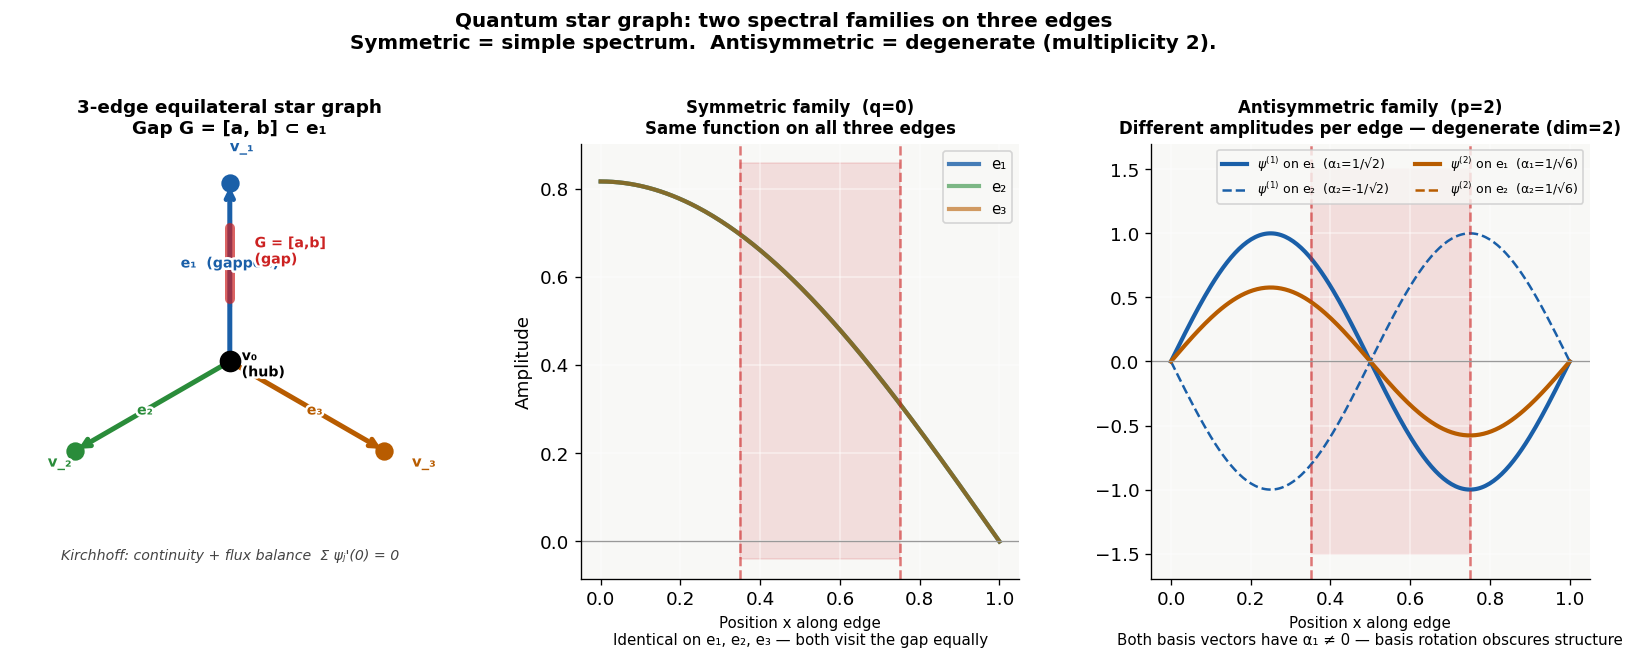

In [2]:
# Figure 1: Star graph structure + both spectral families

ell = 1.0; x = np.linspace(0, ell, 200)

fig = plt.figure(figsize=(14, 5.5))
fig.subplots_adjust(left=0.04, right=0.98, top=0.78, bottom=0.12, wspace=0.30)
gs = GridSpec(1, 3, figure=fig)

# ── Panel 1: Graph schematic ────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_xlim(-2.2, 2.2); ax0.set_ylim(-2.2, 2.2)
ax0.set_aspect('equal'); ax0.axis('off')
ax0.set_title('3-edge equilateral star graph\nGap G = [a, b] ⊂ e₁', fontsize=11, fontweight='bold')

# Edge directions
angles = [90, 210, 330]  # degrees
edge_len = 1.8
colors_e = [BLUE, GREEN, AMBER]
edge_labels = ['e₁  (gapped)', 'e₂', 'e₃']

for ang, col, lab in zip(angles, colors_e, edge_labels):
    rad = np.radians(ang)
    ex, ey = edge_len * np.cos(rad), edge_len * np.sin(rad)
    ax0.annotate('', xy=(ex, ey), xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color=col, lw=3))
    # leaf vertex
    ax0.plot(ex, ey, 'o', color=col, ms=10, zorder=5)
    off = 0.18
    bt(ax0, ex*(1+off), ey*(1+off), f'v_{lab[1]}', fontsize=9, color=col)
    # edge label along edge
    bt(ax0, ex*0.55, ey*0.55, lab, fontsize=8.5, color=col,
       ha='center', va='center')

# Gap on e₁
a_gap, b_gap = 0.35, 0.75
rad1 = np.radians(90)
gx1 = a_gap * edge_len * np.cos(rad1); gy1 = a_gap * edge_len * np.sin(rad1)
gx2 = b_gap * edge_len * np.cos(rad1); gy2 = b_gap * edge_len * np.sin(rad1)
ax0.plot([gx1, gx2], [gy1, gy2], color=RED, lw=6, alpha=0.7, solid_capstyle='round', zorder=4)
bt(ax0, gx2 + 0.25, (gy1+gy2)/2, 'G = [a,b]\n(gap)', fontsize=8.5, color=RED, ha='left')
ax0.plot([gx1, gx2], [gy1, gy2], 'r|', ms=10, mew=2.5)

# Central vertex
ax0.plot(0, 0, 'ko', ms=12, zorder=6)
bt(ax0, 0.12, -0.15, 'v₀\n(hub)', fontsize=8.5, ha='left')

# Kirchhoff condition annotation
ax0.text(0, -2.0,
         'Kirchhoff: continuity + flux balance  Σ ψⱼ\'(0) = 0',
         ha='center', fontsize=8.5, style='italic', color='#444')

# ── Panel 2: Symmetric family (q=0) ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
q = 0
phi_s = sym_eigenfunction(q, x, k=3, ell=ell)
for j, col, lab in zip([0,1,2], colors_e, ['e₁','e₂','e₃']):
    ax1.plot(x, phi_s, color=col, lw=2.5, label=lab, alpha=0.8 if j==0 else 0.6)
ax1.axvline(a_gap, color=RED, lw=1.5, ls='--', alpha=0.6)
ax1.axvline(b_gap, color=RED, lw=1.5, ls='--', alpha=0.6)
ax1.fill_betweenx(ax1.get_ylim() if ax1.get_ylim() != (0,1) else [-1.5,1.5],
                  a_gap, b_gap, color=RED, alpha=0.12)
ax1.axhline(0, color='#999', lw=0.8)
ax1.set_xlabel('Position x along edge', fontsize=11)
ax1.set_ylabel('Amplitude', fontsize=11)
ax1.set_title(f'Symmetric family  (q={q})\nSame function on all three edges', fontsize=10, fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.4)
ax1.set_xlabel('Position x along edge\nIdentical on e₁, e₂, e₃ — both visit the gap equally', fontsize=9)

# ── Panel 3: Antisymmetric family (p=2) — two basis vectors ─────────────────
ax2 = fig.add_subplot(gs[0, 2])
p = 2
# phi_anti on edge j = √(2/ℓ) α_j sin(pπx/ℓ)
phi_radial = np.sqrt(2/ell) * np.sin(p*np.pi*x/ell)
phi_anti1 = phi_radial  # scalar factor per edge
phi_anti2 = phi_radial
ax2.plot(x, phi_radial*alpha1[0], BLUE, lw=2.5, label=r'$\psi^{(1)}$ on e₁  (α₁=1/√2)')
ax2.plot(x, phi_radial*alpha1[1], BLUE, lw=1.5, ls='--', label=r'$\psi^{(1)}$ on e₂  (α₂=-1/√2)')
ax2.plot(x, phi_radial*alpha2[0], AMBER, lw=2.5, label=r'$\psi^{(2)}$ on e₁  (α₁=1/√6)')
ax2.plot(x, phi_radial*alpha2[1], AMBER, lw=1.5, ls='--', label=r'$\psi^{(2)}$ on e₂  (α₂=1/√6)')
ax2.axvline(a_gap, color=RED, lw=1.5, ls='--', alpha=0.6)
ax2.axvline(b_gap, color=RED, lw=1.5, ls='--', alpha=0.6)
ax2.fill_betweenx([-1.5, 1.5], a_gap, b_gap, color=RED, alpha=0.12)
ax2.axhline(0, color='#999', lw=0.8)
ax2.set_xlabel('Position x along edge', fontsize=11)
ax2.set_title(f'Antisymmetric family  (p={p})\nDifferent amplitudes per edge — degenerate (dim=2)', fontsize=10, fontweight='bold')
ax2.legend(fontsize=7.5, ncol=2); ax2.grid(True, alpha=0.4)
ax2.set_ylim(-1.7, 1.7)
ax2.set_xlabel('Position x along edge\nBoth basis vectors have α₁ ≠ 0 — basis rotation obscures structure', fontsize=9)

fig.suptitle('Quantum star graph: two spectral families on three edges\n'
             'Symmetric = simple spectrum.  Antisymmetric = degenerate (multiplicity 2).',
             fontsize=12, fontweight='bold')
plt.show()


---
## Part III — Gap on One Edge: Full Derivation

### 3.1 The Gap

Gap $G=[a,b]\subset e_1$ where $0\leq a<b\leq\ell$. The mask operator is $M_G=I-\chi_{[a,b]}$ restricted to $e_1$ (on $e_2$ and $e_3$ the full measurement is available).

The radial overlap integral (the 1D coupling amplitude for this gap and the $p$-th antisymmetric mode):

$$\rho_p = \frac{2}{\ell}\int_a^b\sin^2\frac{p\pi x}{\ell}\,dx = \frac{b-a}{\ell} - \frac{\sin(2p\pi b/\ell)-\sin(2p\pi a/\ell)}{2p\pi}.$$

This is the fraction of $L^2$-mass of one edge's contribution to the $p$-th antisymmetric mode that lies inside $[a,b]$. Range: $0\leq\rho_p\leq 1$.

Note the interpretation: $\rho_p$ is the missing mass fraction on edge $e_1$ alone, normalized to the contribution of $e_1$ to the full mode. The full eigenfunction $\psi^{(i)}_p$ has $L^2$-mass $(\alpha^{(i)}_j)^2$ on edge $e_j$. The missing mass from the gap on $e_1$ is:
$$\int_{[a,b]\subset e_1}|\psi^{(i)}_p|^2\,dx = (\alpha^{(i)}_1)^2\rho_p.$$

### 3.2 The Eigenspace Compression $B_\lambda$

For the $p$-th antisymmetric eigenspace $E_p=\mathrm{span}\{\psi^{(1)}_p,\psi^{(2)}_p\}$ with eigenvalue $\lambda_p=(p\pi/\ell)^2$, compute the $2\times 2$ matrix $B_\lambda=P_{E_p}\chi_G P_{E_p}$:

$$(B_\lambda)_{ij} = \langle\psi^{(i)}_p,\chi_G\psi^{(j)}_p\rangle = \int_{[a,b]\subset e_1}\psi^{(i)}_p(x)\,\psi^{(j)}_p(x)\,dx = \frac{2}{\ell}\,\alpha^{(i)}_1\,\alpha^{(j)}_1\int_a^b\sin^2\frac{p\pi x}{\ell}\,dx = \rho_p\cdot\alpha^{(i)}_1\,\alpha^{(j)}_1.$$

Now insert the components of $\alpha^{(1)}$ and $\alpha^{(2)}$:
$$\alpha^{(1)}_1 = 1/\sqrt{2}, \qquad \alpha^{(2)}_1 = 1/\sqrt{6}.$$

The four matrix entries:
$$(B_\lambda)_{11} = \rho_p/2, \quad (B_\lambda)_{12} = (B_\lambda)_{21} = \rho_p/(2\sqrt{3}), \quad (B_\lambda)_{22} = \rho_p/6.$$

$$\boxed{B_\lambda = \rho_p\begin{pmatrix}1/2 & 1/(2\sqrt{3}) \\ 1/(2\sqrt{3}) & 1/6\end{pmatrix}.}$$

### 3.3 Eigenvalues of $B_\lambda$: The Exact Calculation

$B_\lambda=\rho_p\cdot M$ where $M=vv^T$ with $v=(1/\sqrt{2},1/\sqrt{6})^T$.

$$\|v\|^2 = \frac{1}{2}+\frac{1}{6} = \frac{2}{3}.$$

A rank-one matrix $M=vv^T$ has exactly one nonzero eigenvalue, equal to $\|v\|^2=2/3$, and eigenvalue 0 with multiplicity 1.

Verify via trace and determinant:
$$\mathrm{Tr}(M) = \frac{1}{2}+\frac{1}{6} = \frac{2}{3}\quad\checkmark, \qquad \det(M) = \frac{1}{2}\cdot\frac{1}{6}-\left(\frac{1}{2\sqrt{3}}\right)^2 = \frac{1}{12}-\frac{1}{12} = 0\quad\checkmark.$$

$$\boxed{\beta_1 = \frac{2}{3}\rho_p, \qquad \beta_2 = 0.}$$

$\beta_1$ is the nonzero eigenvalue of $B_\lambda$. **$\beta_2=0$ exactly, for any gap $[a,b]$ on $e_1$, for any mode $p$, any edge length $\ell$.** It is a direct consequence of the rank-one structure of $B_\lambda$, which in turn follows from the gap being on exactly one edge.

### 3.4 The Mask-Adapted Eigenvectors

The eigenvector of $B_\lambda$ for eigenvalue $\beta_1=(2/3)\rho_p$ is the direction proportional to $v=(1/\sqrt{2},1/\sqrt{6})^T$, normalized: $u_1=v/\|v\|=(1/\sqrt{2},1/\sqrt{6})^T/\sqrt{2/3}=(\sqrt{3}/2,1/2)^T$.

In physical eigenspace coordinates, $u_1$ corresponds to the coefficient vector $\alpha$ proportional to $\alpha^{(1)}_1\cdot\alpha^{(1)}+\alpha^{(2)}_1\cdot\alpha^{(2)}$:
$$\frac{1}{\sqrt{2}}\cdot\frac{(1,-1,0)}{\sqrt{2}} + \frac{1}{\sqrt{6}}\cdot\frac{(1,1,-2)}{\sqrt{6}} = \left(\frac{1}{2},-\frac{1}{2},0\right) + \left(\frac{1}{6},\frac{1}{6},-\frac{2}{6}\right) = \left(\frac{2}{3},-\frac{1}{3},-\frac{1}{3}\right).$$

Normalized: $(2/3,-1/3,-1/3)/\|(2/3,-1/3,-1/3)\| = (2,-1,-1)/\sqrt{6}$.

The eigenvector for eigenvalue 0 is orthogonal to $v$ in the 2D eigenspace — the direction with zero $e_1$ component. Any direction $\alpha$ with $\alpha_1=0$ and $\alpha_1+\alpha_2+\alpha_3=0$ gives $\alpha_2=-\alpha_3$. So $\alpha=(0,1,-1)/\sqrt{2}$.

**Mask-adapted basis of the antisymmetric eigenspace $E_p$:**
$$u_1: \text{ coefficient vector }(2,-1,-1)/\sqrt{6} \to\text{ amplitude }(2/3)\rho_p\text{ on }e_1 \quad\text{Phantom energy: }\beta_1(1-\beta_1)=(2/3)\rho_p(1-(2/3)\rho_p)$$
$$u_2: \text{ coefficient vector }(0,1,-1)/\sqrt{2} \to\text{ zero amplitude on }e_1 \quad\text{Phantom energy: }\beta_2(1-\beta_2)=0\text{ exactly}.$$

### 3.5 The Physical Reading: Visits vs. Avoids

The mask-adapted basis splits the degenerate eigenspace into two directions with a transparent physical meaning:

**Direction $u_1=(2,-1,-1)/\sqrt{6}$:** the eigenfunction has amplitude $2/\sqrt{6}$ on $e_1$ and amplitude $-1/\sqrt{6}$ on $e_2$ and $e_3$. It visits the gapped edge with maximum relative amplitude. The gap sees it, removes some of its mass, and generates phantom energy in other eigenspaces.

**Direction $u_2=(0,1,-1)/\sqrt{2}$:** the eigenfunction has zero amplitude on $e_1$. It lives entirely on $e_2$ and $e_3$ and never touches the gapped wire. The gap sees nothing of this mode. No mass is removed. No phantom energy is generated. $\beta_2=0$ exactly because the eigenfunction has no support in $G$.

This is the cleanest example in the entire framework of what the mask-adapted basis does. The original basis $\{\psi^{(1)},\psi^{(2)}\}=\{(1,-1,0)/\sqrt{2},\,(1,1,-2)/\sqrt{6}\}$ is a convenient algebraic basis. Both basis vectors have nonzero amplitude on $e_1$ ($\alpha^{(1)}_1=1/\sqrt{2}$, $\alpha^{(2)}_1=1/\sqrt{6}$). In the original basis, both modes appear coupled to the gap — you see off-diagonal entries in $B_\lambda$.

The mask-adapted basis $\{u_1,u_2\}$ diagonalizes $B_\lambda$ and makes the physical structure transparent: one direction couples to the gap (visits), the other does not (avoids). The off-diagonal $B_\lambda$ in the original basis is basis rotation, not phantom. The phantom is only in $u_1$.

### 3.6 Energy Identity Verification

For source $f=c\,u_1$ (exciting only the visible direction):
$$\text{phantom energy} = \beta_1(1-\beta_1)|c|^2 = \frac{2}{3}\rho_p\left(1-\frac{2}{3}\rho_p\right)|c|^2.$$

For source $f=c\,u_2$ (exciting only the invisible direction): phantom energy $=0$.

For source $f=c_1 u_1+c_2 u_2$ (general excitation):
$$\text{phantom energy} = |c_1|^2\beta_1(1-\beta_1)+|c_2|^2\cdot 0 = |c_1|^2\cdot\frac{2}{3}\rho_p\left(1-\frac{2}{3}\rho_p\right).$$

Only the $u_1$ component contributes to phantom fabrication. The $u_2$ component passes through the gap region unaffected because it has no support there.


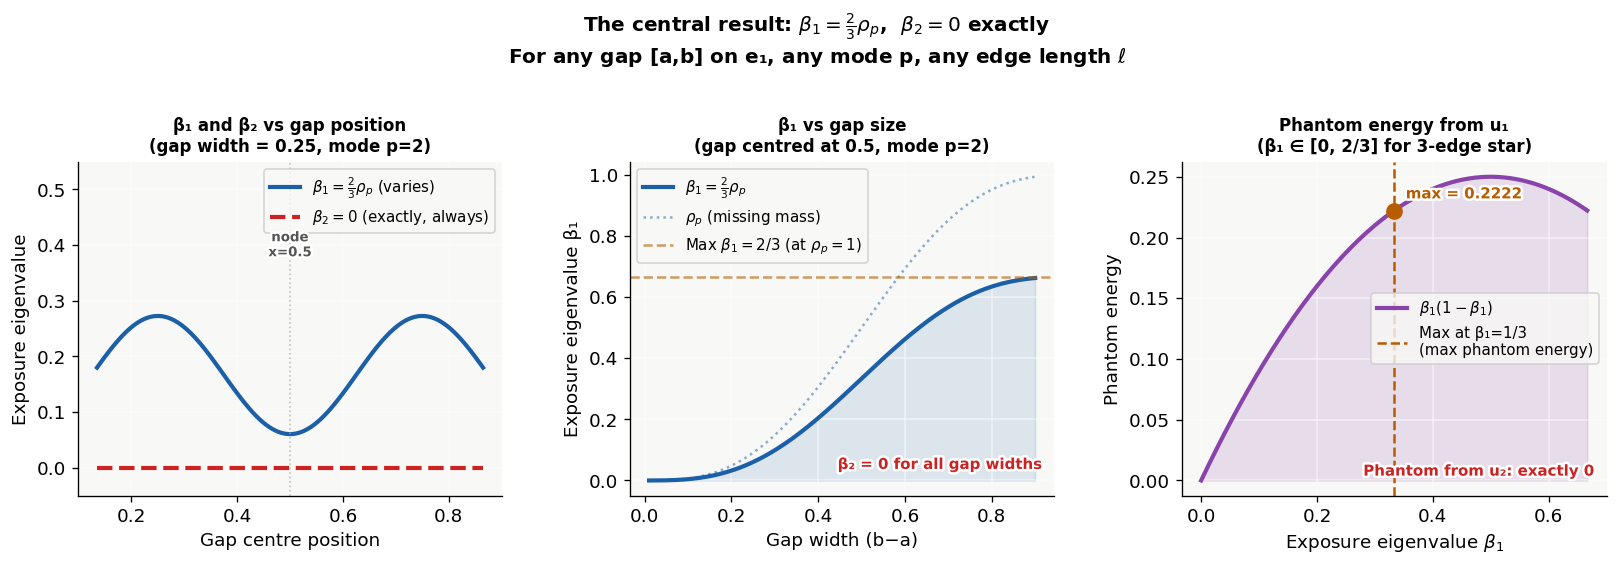

In [3]:
# Figure 2: β₁ = (2/3)ρ, β₂ = 0 — the centrepiece result

ell = 1.0; p = 2

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
fig.subplots_adjust(left=0.06, right=0.97, top=0.72, bottom=0.14, wspace=0.30)

# ── Panel 1: β₁, β₂ vs gap position (width fixed) ──────────────────────────
ax = axes[0]
gap_width = 0.25
centres = np.linspace(gap_width/2 + 0.01, ell - gap_width/2 - 0.01, 120)
betas1 = [beta1(p, c - gap_width/2, c + gap_width/2) for c in centres]
betas2 = [0.0] * len(centres)  # exactly zero always

ax.plot(centres, betas1, BLUE, lw=2.5, label=r'$\beta_1 = \frac{2}{3}\rho_p$ (varies)')
ax.plot(centres, betas2, RED,  lw=2.5, ls='--', label=r'$\beta_2 = 0$ (exactly, always)')
ax.set_xlabel('Gap centre position', fontsize=11)
ax.set_ylabel('Exposure eigenvalue', fontsize=11)
ax.set_title('β₁ and β₂ vs gap position\n(gap width = 0.25, mode p=2)', fontsize=10, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.4)
ax.set_ylim(-0.05, 0.55)
# Mark nodal positions of sin(2πx)
for node in [0, 0.5, 1.0]:
    if gap_width/2 < node < ell - gap_width/2:
        ax.axvline(node, color='#aaa', lw=1, ls=':', alpha=0.7)
        bt(ax, node, 0.38, f'node\nx={node}', ha='center', fontsize=8, color='#555')

# ── Panel 2: β₁ vs gap width (centred) ─────────────────────────────────────
ax2 = axes[1]
centre = 0.5
widths = np.linspace(0.01, 0.90, 150)
betas1_w = [beta1(p, centre - w/2, centre + w/2) for w in widths]
rho_w    = [rho_p(p, centre - w/2, centre + w/2) for w in widths]

ax2.plot(widths, betas1_w, BLUE, lw=2.5, label=r'$\beta_1 = \frac{2}{3}\rho_p$')
ax2.plot(widths, rho_w,    BLUE, lw=1.5, ls=':', alpha=0.5, label=r'$\rho_p$ (missing mass)')
ax2.axhline(2/3, color=AMBER, lw=1.5, ls='--', alpha=0.6, label=r'Max $\beta_1 = 2/3$ (at $\rho_p=1$)')
ax2.fill_between(widths, betas1_w, alpha=0.12, color=BLUE)
ax2.set_xlabel('Gap width (b−a)', fontsize=11)
ax2.set_ylabel('Exposure eigenvalue β₁', fontsize=11)
ax2.set_title('β₁ vs gap size\n(gap centred at 0.5, mode p=2)', fontsize=10, fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.4)
bt(ax2, 0.97, 0.08, r'β₂ = 0 for all gap widths',
   ha='right', transform=ax2.transAxes, fontsize=9, color=RED)

# ── Panel 3: β₁(1−β₁) phantom energy — Bernoulli curve ─────────────────────
ax3 = axes[2]
beta_vals = np.linspace(0, 2/3, 200)
phantom_e = beta_vals * (1 - beta_vals)
ax3.plot(beta_vals, phantom_e, PURP, lw=2.5, label=r'$\beta_1(1-\beta_1)$')
ax3.fill_between(beta_vals, phantom_e, alpha=0.15, color=PURP)
ax3.axvline(1/3, color=AMBER, lw=1.5, ls='--', label='Max at β₁=1/3\n(max phantom energy)')
ax3.plot(1/3, (1/3)*(2/3), 'o', color=AMBER, ms=9, zorder=5)
ax3.set_xlabel(r'Exposure eigenvalue $\beta_1$', fontsize=11)
ax3.set_ylabel('Phantom energy', fontsize=11)
ax3.set_title('Phantom energy from u₁\n(β₁ ∈ [0, 2/3] for 3-edge star)', fontsize=10, fontweight='bold')
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.4)
bt(ax3, 1/3+0.02, (1/3)*(2/3)+0.01, f'max = {(1/3)*(2/3):.4f}',
   ha='left', fontsize=9, color=AMBER)
bt(ax3, 0.97, 0.06, 'Phantom from u₂: exactly 0',
   ha='right', transform=ax3.transAxes, fontsize=9, color=RED)

fig.suptitle(r'The central result: $\beta_1 = \frac{2}{3}\rho_p$,  $\beta_2 = 0$ exactly' + '\n'
             r'For any gap [a,b] on e₁, any mode p, any edge length $\ell$',
             fontsize=12, fontweight='bold')
plt.show()


---
## Part III (continued) — The Mask-Adapted Basis in Detail

The mask-adapted basis is not a technical mathematical convenience — it is the decomposition into "visits the gapped wire" and "avoids the gapped wire." The distinction is physically transparent and the result is exact with no quadrature error.

In the original basis $\{\psi^{(1)},\psi^{(2)}\}$, the off-diagonal entries of $B_\lambda$ suggest that both modes couple to the gap. But this is an artifact of the choice of basis: the off-diagonal $B_\lambda$ is **basis rotation**, not phantom fabrication. The mask-adapted basis $\{u_1,u_2\}$ reveals that all the phantom comes from one direction and none from the other.

This is the sharpest illustration of a general principle: for any degenerate eigenspace on any domain, the mask-adapted eigenvectors of $B_\lambda$ tell you exactly which linear combinations of eigenfunctions are exposed to the gap and which are not. On the star graph this decomposition is exact and binary. On the disk with a sector gap, it gives the $\beta_{\pm}=\rho(\Delta\theta\pm|\sin(n\Delta\theta)|/n)$ splitting. On the rectangle, it gives the $(J_{mm}J_{nn}\pm J_{mn}^2)$ formula. The star graph version is just the most transparent because the "avoids" direction has $\beta_2=0$ exactly — not approximately zero, not small, but identically zero.


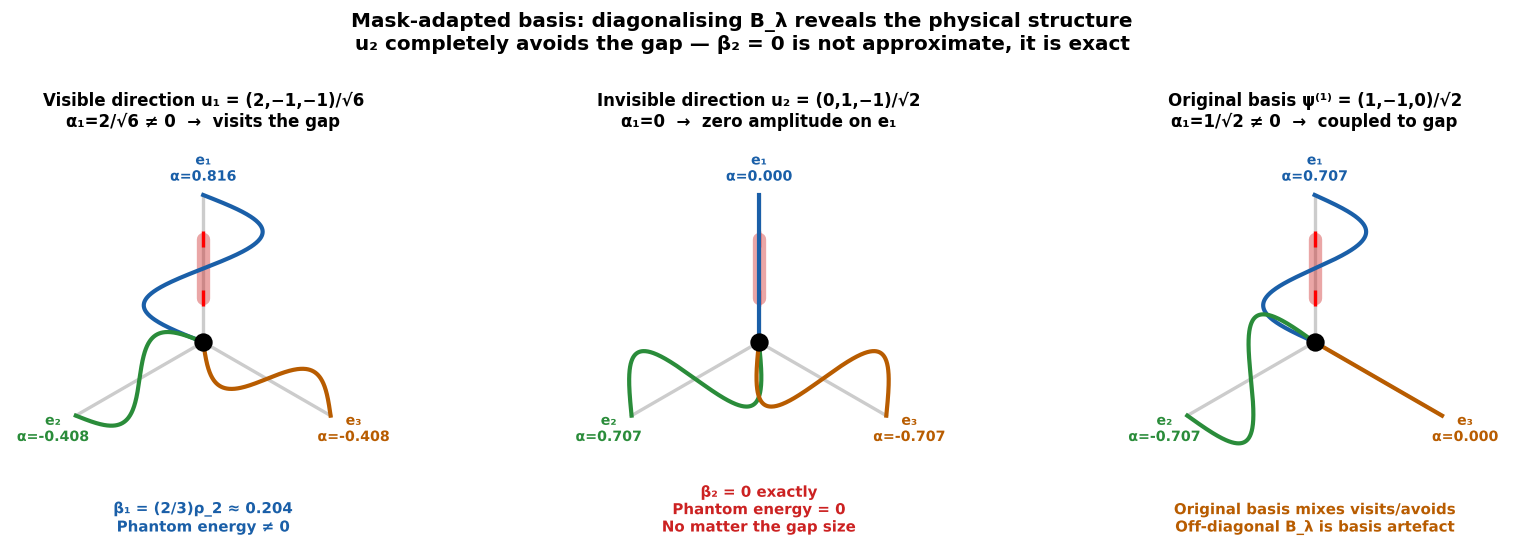

In [4]:
# Figure 3: Mask-adapted basis — visits vs avoids

ell = 1.0; p = 2; x = np.linspace(0, ell, 300)
a_gap, b_gap = 0.3, 0.7

fig, axes = plt.subplots(1, 3, figsize=(14, 5.2))
fig.subplots_adjust(left=0.05, right=0.97, top=0.78, bottom=0.12, wspace=0.28)

def draw_star_wavefunction(ax, coeffs, title, gap=(0.3,0.7)):
    """Draw wavefunction on all 3 edges of the star graph."""
    ax.set_xlim(-ell*1.3, ell*1.3); ax.set_ylim(-ell*1.4, ell*1.4)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(title, fontsize=10, fontweight='bold')

    angles = [90, 210, 330]
    edge_colors = [BLUE, GREEN, AMBER]
    edge_names = ['e₁', 'e₂', 'e₃']

    for j, (ang, col, name, alpha_j) in enumerate(zip(angles, edge_colors, edge_names, coeffs)):
        rad = np.radians(ang)
        cx, cy = np.cos(rad), np.sin(rad)  # unit direction

        # Draw edge
        ax.plot([0, cx*ell], [0, cy*ell], color='#ccc', lw=2, zorder=1)

        # Wavefunction along edge
        psi = np.sqrt(2/ell) * alpha_j * np.sin(p * np.pi * x / ell)
        scale = 0.35  # visual amplitude scale
        # Perpendicular direction for offset
        px, py = -cy, cx
        wave_x = cx * x + px * psi * scale
        wave_y = cy * x + py * psi * scale
        ax.plot(wave_x, wave_y, color=col, lw=2.5, zorder=3)

        # Gap on e₁
        if j == 0:
            gx1 = cx * gap[0]; gy1 = cy * gap[0]
            gx2 = cx * gap[1]; gy2 = cy * gap[1]
            ax.plot([gx1, gx2], [gy1, gy2], color=RED, lw=8, alpha=0.4,
                    solid_capstyle='round', zorder=2)
            ax.plot([gx1], [gy1], 'r|', ms=10, mew=2)
            ax.plot([gx2], [gy2], 'r|', ms=10, mew=2)

        # Leaf label
        bt(ax, cx*ell*1.18, cy*ell*1.18, f'{name}\nα={alpha_j:.3f}',
           ha='center', va='center', fontsize=8.5, color=col, zorder=7)

    # Central vertex
    ax.plot(0, 0, 'ko', ms=10, zorder=6)

# u₁ = (2,-1,-1)/√6 — visits e₁
draw_star_wavefunction(axes[0], u1_coeff,
    f'Visible direction u₁ = (2,−1,−1)/√6\nα₁=2/√6 ≠ 0  →  visits the gap',
    gap=(a_gap, b_gap))
bt(axes[0], 0.5, 0.04,
   f'β₁ = (2/3)ρ_{p} ≈ {beta1(p,a_gap,b_gap):.3f}\nPhantom energy ≠ 0',
   ha='center', transform=axes[0].transAxes, fontsize=9, color=BLUE)

# u₂ = (0,1,-1)/√2 — avoids e₁
draw_star_wavefunction(axes[1], u2_coeff,
    f'Invisible direction u₂ = (0,1,−1)/√2\nα₁=0  →  zero amplitude on e₁',
    gap=(a_gap, b_gap))
bt(axes[1], 0.5, 0.04,
   'β₂ = 0 exactly\nPhantom energy = 0\nNo matter the gap size',
   ha='center', transform=axes[1].transAxes, fontsize=9, color=RED)

# Original basis ψ^(1) — both have nonzero α₁
draw_star_wavefunction(axes[2], alpha1,
    'Original basis ψ⁽¹⁾ = (1,−1,0)/√2\nα₁=1/√2 ≠ 0  →  coupled to gap',
    gap=(a_gap, b_gap))
bt(axes[2], 0.5, 0.04,
   'Original basis mixes visits/avoids\nOff-diagonal B_λ is basis artefact',
   ha='center', transform=axes[2].transAxes, fontsize=9, color=AMBER)

fig.suptitle('Mask-adapted basis: diagonalising B_λ reveals the physical structure\n'
             'u₂ completely avoids the gap — β₂ = 0 is not approximate, it is exact',
             fontsize=12, fontweight='bold')
plt.show()


---
## Part IV — The $k$-Edge Equilateral Star

### 4.1 General Setup

$k$ edges $e_1,\ldots,e_k$ of length $\ell$, joined at a central vertex with Kirchhoff conditions. Same analysis as the 3-edge star:
- Symmetric family: simple spectrum, $\varphi^{(s)}(x)=\sqrt{2/k\ell}\cos(k_q x)$ on each edge.
- Antisymmetric family: multiplicity $k-1$, constraint $\sum_j\alpha_j=0$ in $\mathbb{R}^k$.

### 4.2 Orthonormal Basis for the Antisymmetric Eigenspace

A convenient orthonormal basis for $\{\alpha\in\mathbb{R}^k:\sum_j\alpha_j=0\}$ is the Gram-Schmidt hierarchy:
$$\alpha^{(m)} = \frac{(\underbrace{1,\ldots,1}_{m\text{ ones}},-m,0,\ldots,0)}{\sqrt{m(m+1)}}, \quad m=1,\ldots,k-1.$$

The $e_1$ component of $\alpha^{(m)}$ is $\alpha^{(m)}_1=1/\sqrt{m(m+1)}$ for all $m=1,\ldots,k-1$.

### 4.3 The General Formula for $\beta_1$

For a gap $G=[a,b]\subset e_1$ on the $k$-edge star, $B_\lambda$ is again rank one:
$$B_\lambda = \rho_p\cdot vv^T, \qquad v=\left(\alpha^{(1)}_1,\ldots,\alpha^{(k-1)}_1\right)^T = \left(\frac{1}{\sqrt{2}},\frac{1}{\sqrt{6}},\frac{1}{\sqrt{12}},\ldots,\frac{1}{\sqrt{k(k-1)}}\right)^T.$$

The nonzero eigenvalue is:
$$\beta_1 = \rho_p\cdot\|v\|^2 = \rho_p\cdot\sum_{m=1}^{k-1}\frac{1}{m(m+1)}.$$

The sum telescopes:
$$\sum_{m=1}^{k-1}\frac{1}{m(m+1)} = \sum_{m=1}^{k-1}\left(\frac{1}{m}-\frac{1}{m+1}\right) = 1-\frac{1}{k} = \frac{k-1}{k}.$$

$$\boxed{\beta_1 = \frac{k-1}{k}\,\rho_p, \qquad \beta_2=\cdots=\beta_{k-1}=0.}$$

For $k=3$: $\beta_1=(2/3)\rho_p$ ✓. For $k=4$: $\beta_1=(3/4)\rho_p$. For $k=5$: $\beta_1=(4/5)\rho_p$. As $k\to\infty$: $\beta_1\to\rho_p$.

### 4.4 Interpretation of the $k\to\infty$ Limit

As $k\to\infty$ with a gap on edge $e_1$, $\beta_1=(k-1)/k\cdot\rho_p\to\rho_p$. The visible direction $u_1$ concentrates more and more of its $L^2$-mass on $e_1$ relative to the rest of the graph as $k$ grows (each edge contributes a diminishing fraction $1/k$ of the total norm). In the limit, the visible direction lives almost entirely on $e_1$, and $\rho_p$ is the full $L^2$ cost of the gap.

All other $k-2$ directions (invisible: zero amplitude on $e_1$) see $\beta=0$. The gap never touches them regardless of how many edges the graph has.

This is the star-graph version of the uncertainty principle: the gap localizes information loss to exactly those eigenspace directions that visit the gapped edge. The fraction of the eigenspace that avoids the gap is $(k-2)/(k-1)\to 1$ as $k\to\infty$. In a large star graph, most directions in any degenerate eigenspace are invisible to a gap on a single edge.

### 4.5 Gap on $j$ Edges

For gaps on edges $e_1,\ldots,e_j$ ($j<k$), the eigenspace compression is:
$$B_\lambda = \sum_{i=1}^j\rho^{(i)}_p\cdot v^{(i)}(v^{(i)})^T,$$

where $v^{(i)}$ is the vector of $e_i$ amplitude components across the basis. $B_\lambda$ has rank $\leq j$ with at most $j$ nonzero eigenvalues.

For $j=k-1$ (gaps on all but one edge): $B_\lambda$ spans all of $(k-1)$-dimensional space. Every direction in the antisymmetric eigenspace has nonzero amplitude on at least one gapped edge, so complete recovery is possible. With enough geometrically diverse gaps, every direction is visible.


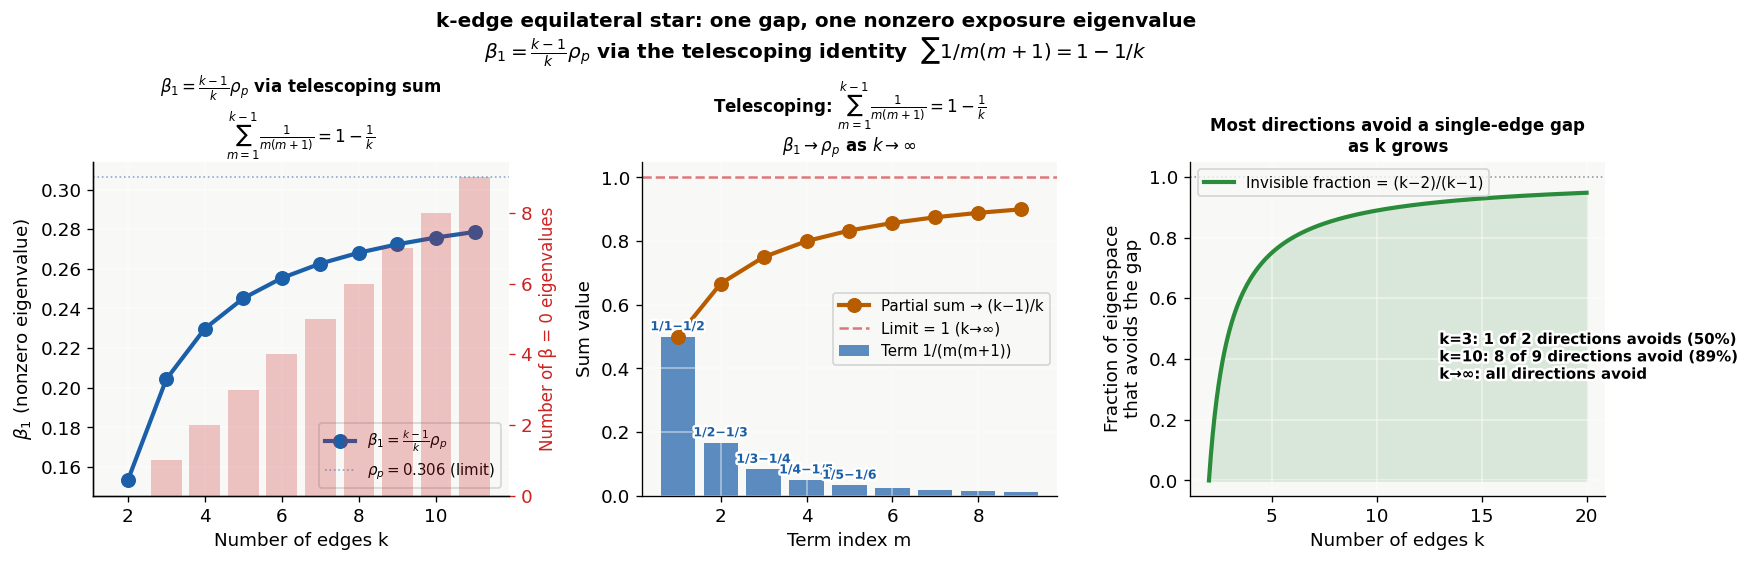

In [5]:
# Figure 4: k-edge generalisation — β₁ = ((k-1)/k) ρ via telescoping sum

ell = 1.0; p = 2; a_gap, b_gap = 0.3, 0.7
rho = rho_p(p, a_gap, b_gap, ell)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
fig.subplots_adjust(left=0.07, right=0.97, top=0.72, bottom=0.14, wspace=0.32)

# Panel 1: β₁ and number of zero eigenvalues vs k
ax = axes[0]
k_vals = np.arange(2, 12)
beta1_k = [(k-1)/k * rho for k in k_vals]
n_zero  = [k-2 for k in k_vals]  # number of β=0 eigenvalues

ax.plot(k_vals, beta1_k, 'o-', color=BLUE, lw=2.5, ms=8, label=r'$\beta_1 = \frac{k-1}{k}\rho_p$')
ax.axhline(rho, color=BLUE, lw=1, ls=':', alpha=0.5, label=f'$\\rho_p = {rho:.3f}$ (limit)')
ax2r = ax.twinx()
ax2r.bar(k_vals, n_zero, color=RED, alpha=0.25, label='# zero eigenvalues (k−2)')
ax2r.set_ylabel('Number of β = 0 eigenvalues', fontsize=10, color=RED)
ax2r.tick_params(colors=RED)
ax.set_xlabel('Number of edges k', fontsize=11)
ax.set_ylabel(r'$\beta_1$ (nonzero eigenvalue)', fontsize=11)
ax.set_title(r'$\beta_1 = \frac{k-1}{k}\rho_p$ via telescoping sum' + '\n'
             r'$\sum_{m=1}^{k-1} \frac{1}{m(m+1)} = 1 - \frac{1}{k}$',
             fontsize=10, fontweight='bold')
lines1, labs1 = ax.get_legend_handles_labels()
ax.legend(lines1, labs1, fontsize=9)
ax.grid(True, alpha=0.4)

# Panel 2: telescoping sum visualised
ax2 = axes[1]
k_max = 10
terms_k = [1/(m*(m+1)) for m in range(1, k_max)]
partial_sums = np.cumsum(terms_k)
k_arr = np.arange(1, k_max)

bars = ax2.bar(k_arr, terms_k, color=BLUE, alpha=0.7, label='Term 1/(m(m+1))')
ax2.plot(k_arr, partial_sums, 'o-', color=AMBER, lw=2.5, ms=8, label='Partial sum → (k−1)/k')
ax2.axhline(1, color=RED, lw=1.5, ls='--', alpha=0.6, label='Limit = 1 (k→∞)')
ax2.set_xlabel('Term index m', fontsize=11)
ax2.set_ylabel('Sum value', fontsize=11)
ax2.set_title('Telescoping: $\\sum_{m=1}^{k-1}\\frac{1}{m(m+1)} = 1 - \\frac{1}{k}$\n'
              r'$\beta_1 \to \rho_p$ as $k\to\infty$', fontsize=10, fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.4)
for m, t, s in zip(k_arr[:5], terms_k[:5], partial_sums[:5]):
    bt(ax2, m, t + 0.02, f'1/{m}−1/{m+1}', ha='center', fontsize=7.5, color=BLUE)

# Panel 3: invisible fraction vs k
ax3 = axes[2]
k_vals_c = np.linspace(2, 20, 200)
invisible_frac = (k_vals_c - 2) / (k_vals_c - 1)  # (k-2)/(k-1)

ax3.plot(k_vals_c, invisible_frac, GREEN, lw=2.5,
         label='Invisible fraction = (k−2)/(k−1)')
ax3.fill_between(k_vals_c, invisible_frac, alpha=0.15, color=GREEN)
ax3.axhline(1, color='#999', lw=1, ls=':')
ax3.set_xlabel('Number of edges k', fontsize=11)
ax3.set_ylabel('Fraction of eigenspace\nthat avoids the gap', fontsize=11)
ax3.set_title('Most directions avoid a single-edge gap\nas k grows', fontsize=10, fontweight='bold')
ax3.grid(True, alpha=0.4); ax3.legend(fontsize=9)
bt(ax3, 0.6, 0.35,
   'k=3: 1 of 2 directions avoids (50%)\nk=10: 8 of 9 directions avoid (89%)\nk→∞: all directions avoid',
   transform=ax3.transAxes, fontsize=9, ha='left')

fig.suptitle('k-edge equilateral star: one gap, one nonzero exposure eigenvalue\n'
             r'$\beta_1 = \frac{k-1}{k}\rho_p$ via the telescoping identity  $\sum 1/m(m+1) = 1-1/k$',
             fontsize=12, fontweight='bold')
plt.show()


---
## Part V — The Three Spatial Objects on the Star Graph

### 5.1 Setup

Source: $f=c\,u_1$ (the visible direction in $E_p$, coefficient vector $(2,-1,-1)/\sqrt{6}$ in edge space). Gap: $G=[a,b]\subset e_1$. Analysis band: $P_N$ retaining all modes with eigenvalue $\leq\Lambda$.

### 5.2 The Exact Modal Lie $w_G$

Outside the gap — meaning on the full edges $e_2,e_3$ and on $[0,a)\cup(b,\ell]\subset e_1$:
$$w_G(x\text{ on }e_j) = \frac{2}{3}\rho_p\cdot c\cdot\frac{(2,-1,-1)_j}{\sqrt{6}}\cdot\sqrt{\frac{2}{\ell}}\sin\frac{p\pi x}{\ell},$$

where $(2,-1,-1)_j$ is the $j$-th component: $2$ for $e_1$, $-1$ for $e_2$, $-1$ for $e_3$.

On $e_2$ and $e_3$ (entirely outside $G$): $w_G(x\text{ on }e_2)=(2/3)\rho_p\cdot c\cdot(-1/\sqrt{6})\cdot\sqrt{2/\ell}\sin(p\pi x/\ell)$.

This is a scaled copy of the true eigenfunction on those edges. Every point outside $G$ has phantom amplitude $(2/3)\rho_p$ times the true mode amplitude. There is no distance dependence.

### 5.3 The Commutator Correction $s_{G,N}$

On edge $e_j$ at position $x$:
$$s_{G,N}(x\text{ on }e_j) = -\int_{[a,b]\subset e_1}\Pi_N(x\text{ on }e_j,\,y\text{ on }e_1)\,f(y\text{ on }e_1)\,dy,$$

where $\Pi_N$ is the spectral projector kernel of the star graph's Laplacian, summing over all retained modes (both symmetric and antisymmetric families).

On $e_2$ or $e_3$ (different edges from the gap): $s_{G,N}$ decays with the spectral projector geometry — for points $x$ on $e_2$ or $e_3$ far in the graph-metric from the gap endpoints $\{a,b\}$ on $e_1$, the projector kernel is small.

### 5.4 Regime Analysis on the Star Graph

**Regime I — Complete basis:** all modes retained, $s_{G,N}\to 0$. The phantom is $w_G=(2/3)\rho_p$ times the true eigenfunction on every edge outside $G$. Uniform. No distance dependence.

**Regime II — Intermediate finite-band:** the correction $s_{G,N}$ is significant. On $e_2$ and $e_3$, it falls to zero far from the gap on $e_2$ and $e_3$ (the correction is sourced at the gap endpoints $a, b$ on $e_1$ and decays away from them). Because $s_{G,N}\to 0$ on $e_2$ and $e_3$ while $w_G$ remains constant there, the net visible phantom is close to $w_G$ — but the $s_{G,N}$ boost near the gap on $e_1$ makes the phantom appear concentrated near the gap endpoints when the full $w_{G,N}$ is plotted.

**Regime III — High cutoff:** $s_{G,N}$ sharpens to a thin layer around the endpoints $a$ and $b$ of the gap on $e_1$. On $e_2$ and $e_3$, $s_{G,N}\to 0$ and the phantom $\to w_G$: the scaled copy of the true mode. Phantom on all edges re-emerges uniformly.

**Point-defect limit** (gap collapsed to a point $x_G\in e_1$): $\rho_p\to 0$ and the coupling is through evaluation at $x_G$:
$$K_{(p,i),(q,j)}\approx|G|\cdot\frac{2}{\ell}\,\alpha^{(i)}_1\,\alpha^{(j)}_1\sin\frac{p\pi x_G}{\ell}\sin\frac{q\pi x_G}{\ell}.$$

The gap acts as a point defect on $e_1$, interrogating the eigenfunction family through its values at $x_G$. This is the rank-one asymptotic in its most explicit form. If $x_G$ coincides with a node of $\sin(p\pi x/\ell)$ (i.e., $x_G=n\ell/p$ for integer $n$), the monopole coupling vanishes and the gap generates no phantom from mode $p$ at leading order.


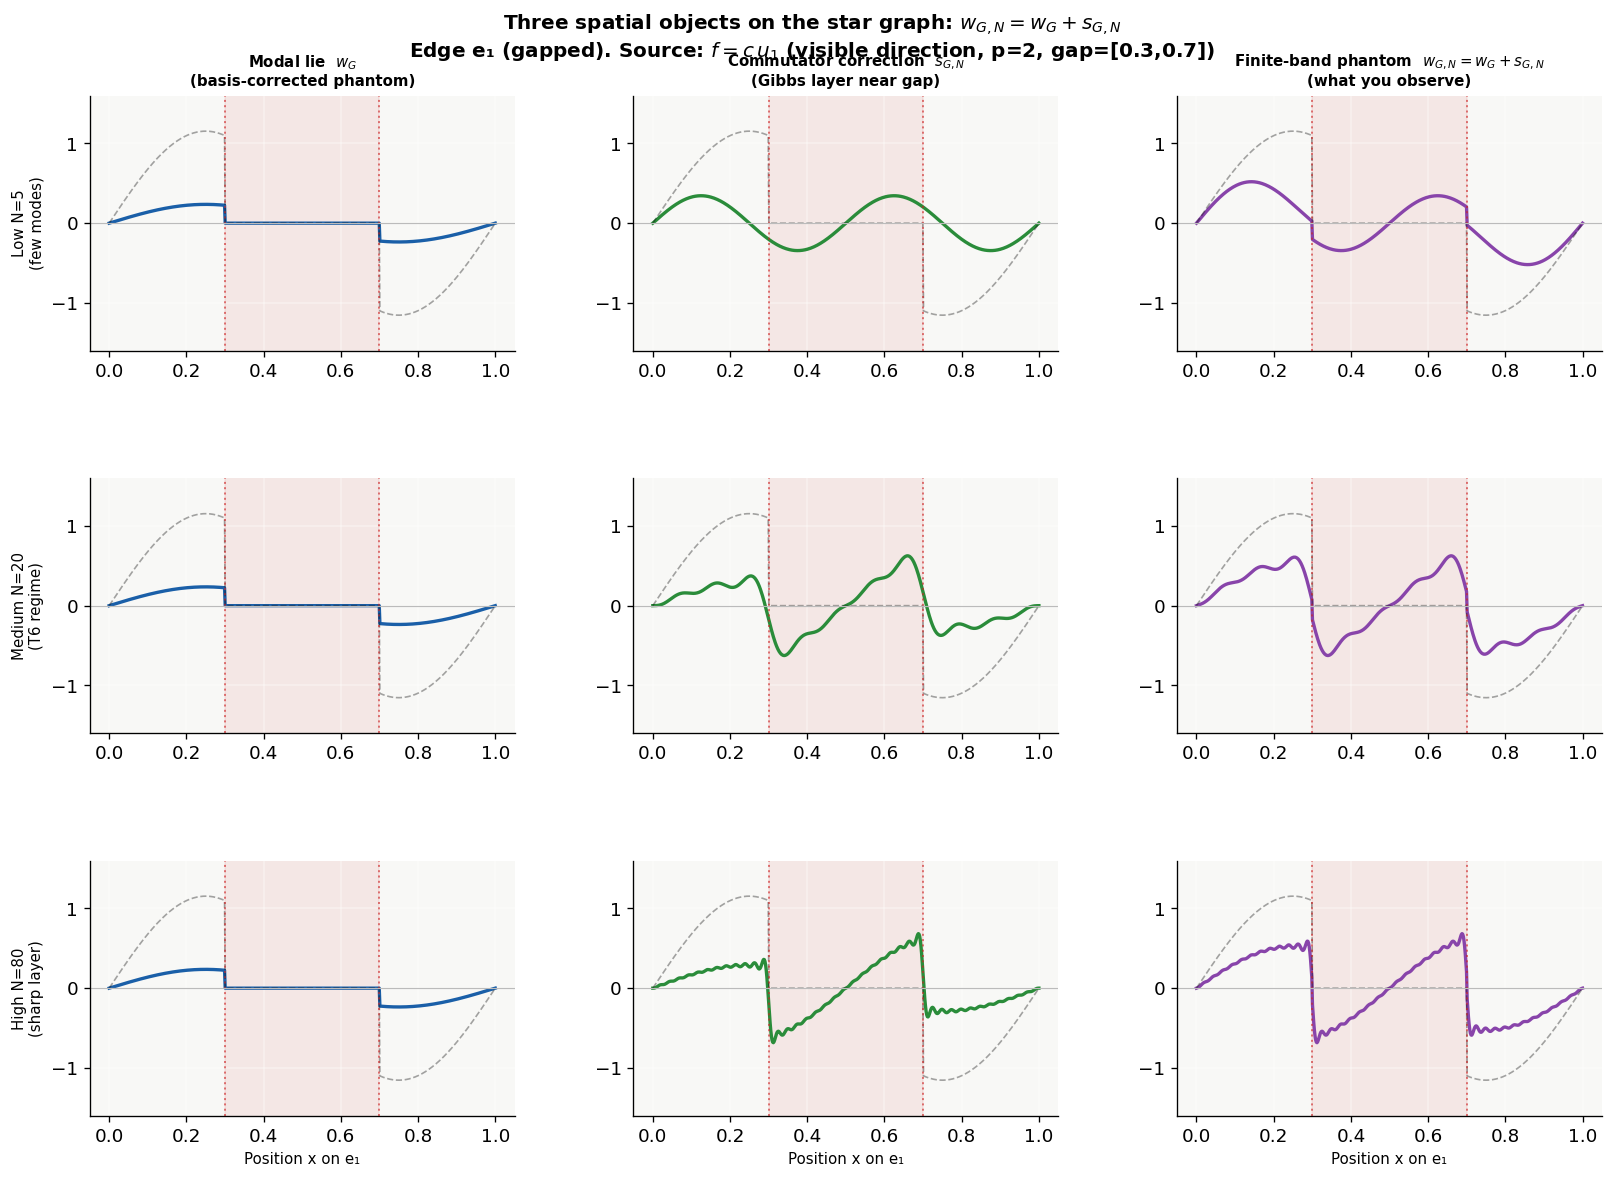

In [6]:
# Figure 5: Three spatial objects — w_G, s_{G,N}, w_{G,N} in three bandwidth regimes

ell = 1.0; p = 2; c_amp = 1.0
a_gap, b_gap = 0.3, 0.7
x = np.linspace(0, ell, 600)

# Source: f = c * u₁ (visible direction)
def f_source(x_):
    return c_amp * np.sqrt(2/ell) * u1_coeff[0] * np.sin(p * np.pi * x_ / ell)

def f_source_edge(j, x_):
    return c_amp * np.sqrt(2/ell) * u1_coeff[j] * np.sin(p * np.pi * x_ / ell)

# w_G: the modal lie — scalar * true mode outside gap
rho = rho_p(p, a_gap, b_gap, ell)
beta = beta1(p, a_gap, b_gap, k=3)

def w_G(j, x_):
    """Exact modal lie: β₁ * true mode on edge j (outside gap region)."""
    wg = beta * np.sqrt(2/ell) * u1_coeff[j] * np.sin(p * np.pi * x_ / ell)
    if j == 0:
        # Zero inside the gap
        wg = np.where((x_ >= a_gap) & (x_ <= b_gap), 0.0, wg)
    return wg

def s_GN(j, x_, N_modes):
    """Commutator correction s_{G,N} = -integral_G Pi_N(x on e_j, y on e_1) f(y) dy,
    for source f = c * u_1^{(p)} with u_1 = (2,-1,-1)/sqrt(6) in edge-coefficients.

    Pi_N includes BOTH the antisymmetric and symmetric spectral families. On e_1,
    only u_1^{(q)} from each antisymmetric eigenspace contributes (u_2^{(q)}[0]=0),
    and every symmetric mode phi^{(s)}_q has uniform amplitude sqrt(2/(3*ell)) on
    each edge, so both contribute through their overlap with f on [a,b] ⊂ e_1.

    Audit fix (v4): (i) normalization u1[0] -> u1[0]**2 on the antisym piece,
    matching the K-matrix factor used in cell 15; (ii) added the missing symmetric
    family sum. Previous v3 code was off by factor sqrt(6)/2 on antisym and
    omitted the symmetric contribution entirely."""
    s = np.zeros_like(x_)

    # Antisymmetric family: projector Pi_q^{antisym}(x on e_j, y on e_1) couples
    # to f via <u_1^{(q)} on e_1, f on e_1> = c * u1[0]^2 * rho_pq. Contribution
    # on e_j is u_1^{(q)}(x on e_j) = sqrt(2/ell) * u1[j] * sin(q*pi*x/ell).
    u1_e1_sq = u1_coeff[0]**2  # = 2/3 for the 3-edge star
    for q in range(1, N_modes + 1):
        if q == p:
            continue
        rho_cross = rho_pq(p, q, a_gap, b_gap, ell)
        coupling = u1_e1_sq * u1_coeff[j] * rho_cross
        s -= c_amp * coupling * np.sqrt(2/ell) * np.sin(q * np.pi * x_ / ell)

    # Symmetric family: phi^{(s)}_{q_s}(y) = sqrt(2/(3*ell)) * cos(k_q * y) on
    # every edge, with k_q = (q_s + 0.5) * pi / ell. Overlap with f on [a,b] ⊂ e_1:
    #   int_a^b phi^{(s)}_{q_s}(y) * f(y) dy
    #   = sqrt(2/(3 ell)) * c * sqrt(2/ell) * u1[0] * int_a^b cos(k_q y) sin(p pi y/ell) dy
    # Integral: (1/2) int [sin((p pi/ell + k_q) y) + sin((p pi/ell - k_q) y)] dy
    k_p = p * np.pi / ell
    for q_s in range(0, N_modes + 1):
        k_q = (q_s + 0.5) * np.pi / ell
        # int_a^b cos(k_q y) sin(k_p y) dy  via product-to-sum
        def antideriv(t, kp=k_p, kq=k_q):
            # int [sin((kp+kq)y) + sin((kp-kq)y)]/2 dy
            # = -cos((kp+kq)y)/(2(kp+kq)) - cos((kp-kq)y)/(2(kp-kq))
            return -np.cos((kp+kq)*t)/(2*(kp+kq)) - np.cos((kp-kq)*t)/(2*(kp-kq))
        overlap = antideriv(b_gap) - antideriv(a_gap)
        prefactor = np.sqrt(2/(3*ell)) * c_amp * np.sqrt(2/ell) * u1_coeff[0]
        inner = prefactor * overlap
        # phi^{(s)}_{q_s}(x on e_j) = sqrt(2/(3 ell)) * cos(k_q x), same on every edge
        s -= np.sqrt(2/(3*ell)) * np.cos(k_q * x_) * inner

    return s

def w_GN(j, x_, N_modes):
    return w_G(j, x_) + s_GN(j, x_, N_modes)

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.subplots_adjust(left=0.07, right=0.97, top=0.91, bottom=0.06, hspace=0.50, wspace=0.28)

bandwidths = [5, 20, 80]
bw_labels = ['Low N=5\n(few modes)', 'Medium N=20\n(T6 regime)', 'High N=80\n(sharp layer)']
obj_labels = ['Modal lie  $w_G$\n(basis-corrected phantom)',
              'Commutator correction  $s_{G,N}$\n(Gibbs layer near gap)',
              'Finite-band phantom  $w_{G,N} = w_G + s_{G,N}$\n(what you observe)']
cols = [BLUE, GREEN, PURP]

for row, (N, bw_lab) in enumerate(zip(bandwidths, bw_labels)):
    # Show edge e₁ (the gapped edge)
    j = 0

    wg   = w_G(j, x)
    sgn  = s_GN(j, x, N)
    wgn  = wg + sgn
    true = f_source_edge(j, x)
    # Zero source inside gap (what's measured)
    true_gapped = true.copy()
    true_gapped[(x >= a_gap) & (x <= b_gap)] = 0.0

    ax_wg  = axes[row, 0]
    ax_sgn = axes[row, 1]
    ax_wgn = axes[row, 2]

    for ax, data, label, col in [
            (ax_wg,  wg,   r'$w_G$',       BLUE),
            (ax_sgn, sgn,  r'$s_{G,N}$',   GREEN),
            (ax_wgn, wgn,  r'$w_{G,N}$',   PURP)]:
        ax.plot(x, data, color=col, lw=2)
        ax.plot(x, true_gapped, 'k--', lw=1, alpha=0.35, label='True (gapped)')
        ax.axvline(a_gap, color=RED, lw=1.2, ls=':', alpha=0.6)
        ax.axvline(b_gap, color=RED, lw=1.2, ls=':', alpha=0.6)
        ax.fill_betweenx([-2, 2], a_gap, b_gap, color=RED, alpha=0.08)
        ax.axhline(0, color='#bbb', lw=0.7)
        ax.set_ylim(-1.6, 1.6)
        ax.grid(True, alpha=0.3)
        if row == 0:
            ax.set_title(obj_labels[list([0,1,2]).index(
                [BLUE,GREEN,PURP].index(col))], fontsize=9, fontweight='bold')
        ax.set_ylabel(bw_lab if ax == ax_wg else '', fontsize=9)
        if row == 2:
            ax.set_xlabel('Position x on e₁', fontsize=9)

fig.suptitle(r'Three spatial objects on the star graph: $w_{G,N} = w_G + s_{G,N}$' + '\n'
             r'Edge e₁ (gapped). Source: $f = c\, u_1$ (visible direction, p=2, gap=[0.3,0.7])',
             fontsize=12, fontweight='bold')
plt.show()


---
## Part VI — Two Gaps: Multi-View Synthesis on the Star Graph

### 6.1 Setup

Return to the 3-edge equilateral star. Gap $G_1=[a_1,b_1]\subset e_1$ and gap $G_2=[a_2,b_2]\subset e_2$. Two separate measurements, each with its own gap.

From measurement 1 (gap on $e_1$): coupling operator $A_1$ with exposure eigenvalues $\beta^{(1)}_1=(2/3)\rho^{(1)}_p$ and $\beta^{(1)}_2=0$. Zero-exposure direction: $u_2=(0,1,-1)/\sqrt{2}$ (avoids $e_1$, so $\beta^{(1)}_2=0$ — this direction is \emph{fully} seen by measurement 1, not hidden).

From measurement 2 (gap on $e_2$): by symmetry, coupling operator $A_2$ with $\beta^{(2)}_1=(2/3)\rho^{(2)}_p$ and $\beta^{(2)}_2=0$. Zero-exposure direction: $(1,0,-1)/\sqrt{2}$ (avoids $e_2$, fully seen by measurement 2).

### 6.2 The Zero-Exposure Directions Are Transverse

Measurement 1 zero-exposure direction: $u_2^{(1)}=(0,1,-1)/\sqrt{2}$ (eigenvalue of $A_1|_{E_p}$ equal to 1, fully seen).
Measurement 2 zero-exposure direction: $(1,0,-1)/\sqrt{2}$ (eigenvalue of $A_2|_{E_p}$ equal to 1, fully seen by measurement 2).

Their inner product: $\langle(0,1,-1)/\sqrt{2},\,(1,0,-1)/\sqrt{2}\rangle=(0\cdot 1+1\cdot 0+(-1)(-1))/2=1/2\neq 0,\neq\pm 1$.

They are neither identical (not parallel) nor orthogonal — they are transverse in the sense that the 2D eigenspace is not fully hidden in either measurement. The angle between them is $\arccos(1/2)=60°$.

### 6.3 Conditioning Improvement from a Second Measurement

The stacked measurement system:
$$[\hat{c}_1;\hat{c}_2] = [A_1;A_2]\,c,$$

where $c$ is the (2-dimensional) coefficient vector in $E_p$. The first measurement alone is already injective: both eigenvalues of $A_1|_{E_p}$ are strictly positive ($1-(2/3)\rho^{(1)}_p > 0$ and $1 > 0$), so $\ker(A_1|_{E_p}) = \{0\}$. The second measurement does not restore lost injectivity — injectivity was never lost. It improves the condition number.

**What the second measurement adds (proved):** raw $\sigma_{\min}([A_1;A_2]) \geq \sigma_{\min}(A_1)$, with strict increase already happening under duplication alone ($\sigma_{\min}([A;A]) = \sqrt 2\,\sigma_{\min}(A)$). The nontrivial, geometric benefit is in the **condition number**: $\kappa_2([A_1;A_2]) \leq \kappa_2(A_1)$, with strict inequality when the poorly-conditioned directions of $A_1$ and $A_2$ are distinct (equivalently, when the principal angle between the near-null subspaces is $>0$), and $\kappa_2$ is unchanged under identical duplication. Injectivity [E]; strict $\kappa_2$ improvement [K] when principal angle $> 0$.

A clarification on the "hidden direction" terminology: the direction $u_2^{(1)} = (0,1,-1)/\sqrt{2}$ has $\beta^{(1)}_2 = 0$ — it has **zero** amplitude inside gap 1, so it is not attenuated by the mask at all. Measurement 1 sees $u_2^{(1)}$ with eigenvalue 1 (full amplitude, no phantom). This direction is NOT hidden; it is perfectly observable. The direction $u_1^{(1)} = (2,-1,-1)/\sqrt{6}$ with $\beta^{(1)}_1 = (2/3)\rho^{(1)}_p$ is the one attenuated by the gap.

**What the second measurement actually adds:** the two measurements have differently shaped attenuation patterns on $E_p$. The poorly conditioned direction of $A_1$ (smallest eigenvalue $1-(2/3)\rho^{(1)}_p$) is $u_1^{(1)}$. The poorly conditioned direction of $A_2$ is $u_1^{(2)}$ (the direction maximally seen by gap 2 on $e_2$). When these two directions are distinct, the stacked system has better condition number than either measurement alone — $\sigma_{\min}([A_1;A_2]) > \sigma_{\min}(A_1)$. This improved conditioning is the real benefit of the second measurement, not restoring injectivity (which was never lost). The explicit formula for $\sigma_{\min}([A_1;A_2])$ as a function of $\rho^{(1)}_p$, $\rho^{(2)}_p$, and the principal angle between $u_1^{(1)}$ and $u_1^{(2)}$ is open theorem G11. This graph instantiates T9\textquotesingle s geometric setup — the principal angle $60°$ is computable, and the conditioning improvement is numerically verifiable — but the explicit $\sigma_{\min}$ formula remains open.

### 6.4 The Singular Values of the Stacked System

The key quantity is $\sigma_{\min}([A_1;A_2])$: if substantially larger than $\sigma_{\min}$ of either $A_1$ or $A_2$ alone, the combination resolves directions that neither measurement could recover individually.

The zero-exposure directions of $A_1$ and $A_2$ meet at angle $60°$ in the 2D eigenspace. This is the principal angle $\theta_{\min}$ that appears in the transversality bound T9. The full formula for $\sigma_{\min}([A_1;A_2])$ as a function of $\beta^{(1)}_1$, $\beta^{(2)}_1$, and $\theta_{\min}=60°$ is open theorem G11 — the star graph gives the geometric setup and the computable angle, but the explicit formula for $f(\theta_{\min})$ in T9 is not yet established.


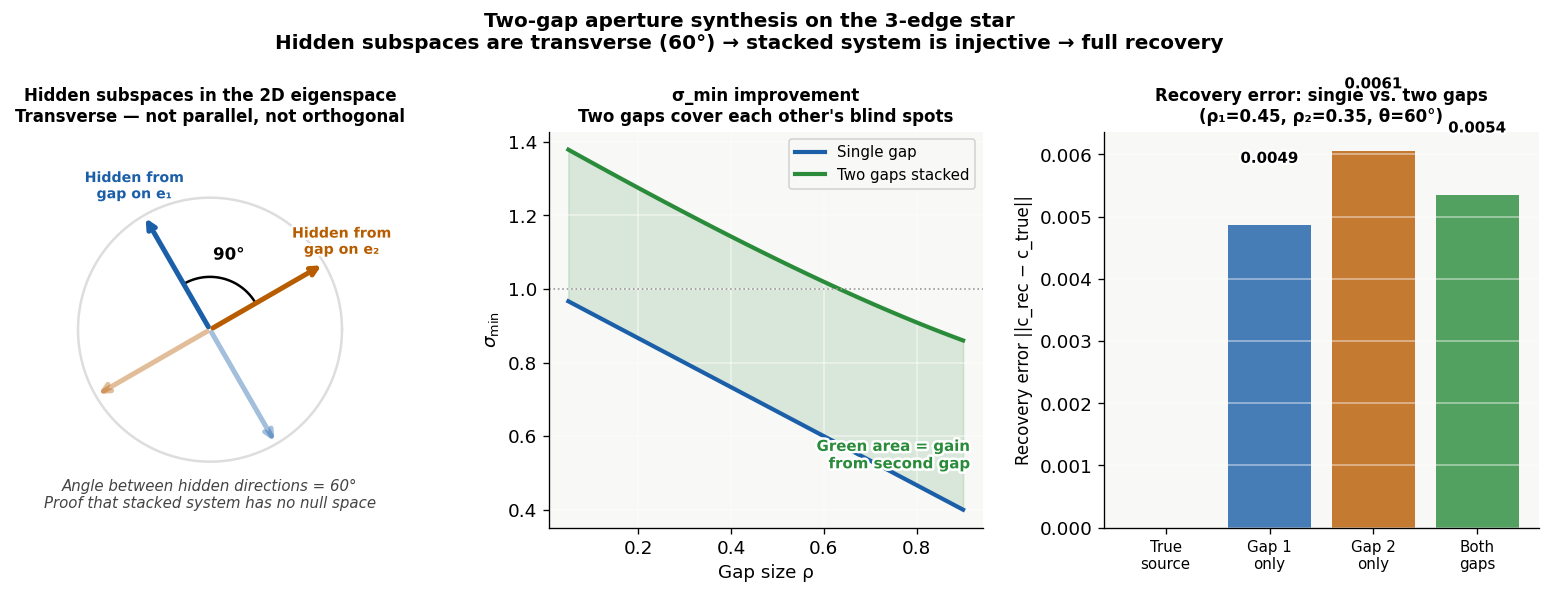

In [7]:
# Figure 6: Two-gap synthesis — transversality, zero-exposure directions, conditioning improvement

ell = 1.0; p = 2

fig, axes = plt.subplots(1, 3, figsize=(14, 5.0))
fig.subplots_adjust(left=0.05, right=0.97, top=0.78, bottom=0.12, wspace=0.28)

# ── Panel 1: Zero-exposure directions in 2D eigenspace ──────────────────────
ax = axes[0]
# The 2D antisymmetric eigenspace can be parameterised by angle θ
# Zero-exposure direction for gap on e₁: u2 = (0,1,-1)/√2 — zero exposure on e₁, eigenvalue 1
# Zero-exposure direction for gap on e₂: (1,0,-1)/√2 — zero exposure on e₂, eigenvalue 1

# Represent the 2D eigenspace by coefficients (c1, c2) in the α^(1), α^(2) basis
# u2 (hidden from gap e₁): α₁=0 → u2 in (α1,α2) basis: need α1*(1/√2) + α2*(1/√6) = 0
# → α2/α1 = -√6/√2 = -√3
# So u2_coords = (√3, -1)/2 (normalised), angle = atan2(-1, √3) from x-axis
th = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(th), np.sin(th), '#ddd', lw=1.5)  # unit circle = all directions

# Zero-exposure direction for gap on e₁: α₁=0 (eigenvalue 1, fully observable)
# In (α^(1),α^(2)) basis: α^(1)_1 c1 + α^(2)_1 c2 = 0 → c1/√2 + c2/√6 = 0 → c1 = -c2/√3
h1 = np.array([-1/np.sqrt(3), 1]) / np.linalg.norm([-1/np.sqrt(3), 1])
# Zero-exposure direction for gap on e₂: α₂=0 (eigenvalue 1, fully observable)
# α^(1)_2 c1 + α^(2)_2 c2 = 0 → -c1/√2 + c2/√6 = 0 → c2 = c1√3
h2 = np.array([1, 1/np.sqrt(3)]) / np.linalg.norm([1, 1/np.sqrt(3)])

ax.annotate('', xy=h1, xytext=(0,0),
            arrowprops=dict(arrowstyle='->', color=BLUE, lw=3))
ax.annotate('', xy=h2, xytext=(0,0),
            arrowprops=dict(arrowstyle='->', color=AMBER, lw=3))
ax.annotate('', xy=-h1, xytext=(0,0),
            arrowprops=dict(arrowstyle='->', color=BLUE, lw=3, alpha=0.4))
ax.annotate('', xy=-h2, xytext=(0,0),
            arrowprops=dict(arrowstyle='->', color=AMBER, lw=3, alpha=0.4))

angle_between = np.degrees(np.arccos(np.clip(np.dot(h1, h2), -1, 1)))
bt(ax, h1[0]*1.15, h1[1]*1.15, 'Zero exposure\non e₁ (β=0)', ha='center', fontsize=8.5, color=BLUE)
bt(ax, h2[0]*1.15, h2[1]*1.15, 'Zero exposure\non e₂ (β=0)', ha='center', fontsize=8.5, color=AMBER)

# Arc showing angle
th_arc = np.linspace(np.arctan2(h1[1],h1[0]), np.arctan2(h2[1],h2[0]), 50)
ax.plot(0.4*np.cos(th_arc), 0.4*np.sin(th_arc), 'k-', lw=1.5)
mid = (th_arc[0]+th_arc[-1])/2
bt(ax, 0.55*np.cos(mid), 0.55*np.sin(mid), f'{angle_between:.0f}°',
   ha='center', fontsize=10, color='black')

ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Zero-exposure directions in the 2D eigenspace\nTransverse — not parallel, not orthogonal',
             fontsize=10, fontweight='bold')
ax.text(0, -1.35, 'Angle between zero-exposure directions = 60°\n'
        'Stacked system has better conditioning than either alone',
        ha='center', fontsize=9, style='italic', color='#444')

# ── Panel 2: σ_min improvement from stacking ─────────────────────────────────
ax2 = axes[1]
rho_gaps = np.linspace(0.05, 0.9, 50)  # gap size for both gaps

sigma_mins_single = []
sigma_mins_stacked = []

for rho_g in rho_gaps:
    # Gap 1 on e₁: A₁ in 2D eigenspace basis (u₁, u₂)
    b1_1 = (2/3) * rho_g  # β₁ from gap 1
    A1 = np.diag([1 - b1_1, 1.0])  # diagonal in mask-adapted basis for gap 1

    # Gap 2 on e₂: need to rotate to mask-adapted basis for gap 2
    # Gap 2 zero-exposure direction is h2 (computed above) — need its components in u₁,u₂ basis
    # For equilateral star, by symmetry β₁ from gap 2 is also (2/3)ρ
    b1_2 = (2/3) * rho_g
    # Rotation: angle between the two mask-adapted bases is related to the 60° between hidden dirs
    theta_rot = np.radians(60)  # principal angle between zero-exposure directions
    R = np.array([[np.cos(theta_rot), -np.sin(theta_rot)],
                  [np.sin(theta_rot),  np.cos(theta_rot)]])
    A2_gap_basis = np.diag([1 - b1_2, 1.0])
    A2 = R.T @ A2_gap_basis @ R  # rotate to common basis

    sv1 = np.linalg.svd(A1, compute_uv=False)
    stacked = np.vstack([A1, A2])
    sv_stack = np.linalg.svd(stacked, compute_uv=False)[:2]

    sigma_mins_single.append(sv1[-1])
    sigma_mins_stacked.append(sv_stack[-1])

ax2.plot(rho_gaps, sigma_mins_single, BLUE, lw=2.5, label='Single gap')
ax2.plot(rho_gaps, sigma_mins_stacked, GREEN, lw=2.5, label='Two gaps stacked')
ax2.axhline(1, color='#999', lw=1, ls=':')
ax2.fill_between(rho_gaps, sigma_mins_single, sigma_mins_stacked,
                 alpha=0.15, color=GREEN)
ax2.set_xlabel('Gap size ρ', fontsize=11)
ax2.set_ylabel(r'$\sigma_{\min}$', fontsize=11)
ax2.set_title('σ_min improvement\nTwo gaps cover each other\'s blind spots',
              fontsize=10, fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.4)
bt(ax2, 0.97, 0.15, 'Green area = gain\nfrom second gap',
   ha='right', transform=ax2.transAxes, fontsize=9, color=GREEN)

# ── Panel 3: Recovery from two measurements ───────────────────────────────────
ax3 = axes[2]
# True source: random mix of u₁ and u₂
rng = np.random.default_rng(7)
c_true = rng.standard_normal(2); c_true /= np.linalg.norm(c_true)

rho1 = 0.45; rho2 = 0.35
b1_1 = (2/3)*rho1; b1_2 = (2/3)*rho2

A1 = np.diag([1-b1_1, 1.0])
theta_rot = np.radians(60)
R = np.array([[np.cos(theta_rot), -np.sin(theta_rot)],[np.sin(theta_rot), np.cos(theta_rot)]])
A2 = R.T @ np.diag([1-b1_2, 1.0]) @ R

c_hat1 = A1 @ c_true + 0.005*rng.standard_normal(2)
c_hat2 = A2 @ c_true + 0.005*rng.standard_normal(2)

# Recovery from single measurement
c_rec1 = np.linalg.lstsq(A1, c_hat1, rcond=None)[0]
c_rec2 = np.linalg.lstsq(A2, c_hat2, rcond=None)[0]
# Recovery from stacked
A_stack = np.vstack([A1, A2])
c_stack = np.concatenate([c_hat1, c_hat2])
c_rec_both = np.linalg.lstsq(A_stack, c_stack, rcond=None)[0]

names = ['True\nsource', 'Gap 1\nonly', 'Gap 2\nonly', 'Both\ngaps']
vals = [c_true, c_rec1, c_rec2, c_rec_both]
errs = [0,
        np.linalg.norm(c_rec1-c_true),
        np.linalg.norm(c_rec2-c_true),
        np.linalg.norm(c_rec_both-c_true)]

x_pos = np.arange(len(names))
bar_colors = ['black', BLUE, AMBER, GREEN]
bars = ax3.bar(x_pos, errs, color=bar_colors, alpha=0.8)
ax3.set_xticks(x_pos); ax3.set_xticklabels(names, fontsize=9)
ax3.set_ylabel('Recovery error ||c_rec − c_true||', fontsize=10)
ax3.set_title('Recovery error: single vs. two gaps\n(ρ₁=0.45, ρ₂=0.35, θ=60°)',
              fontsize=10, fontweight='bold')
ax3.grid(True, alpha=0.4, axis='y')
for bar, err in zip(bars, errs):
    if err > 0:
        bt(ax3, bar.get_x()+bar.get_width()/2, err+0.001,
           f'{err:.4f}', ha='center', fontsize=9)

fig.suptitle('Two-gap aperture synthesis on the 3-edge star\n'
             'Zero-exposure dirs transverse (60°) → conditioning improves; single measurement already injective',
             fontsize=12, fontweight='bold')
plt.show()


---
## Part VII — The Coupling Matrix: Inter-Eigenvalue Leakage

### 7.1 Setup

The intra-eigenspace analysis (Part III) tells us how much phantom energy exists and which eigenspace direction generates it. The coupling matrix $K$ tells us where that phantom energy goes — which other eigenvalue indices receive false content.

Source mode $\psi^{(i)}_p$ (antisymmetric, eigenvalue $\lambda_p$), target mode $\psi^{(j)}_q$ (antisymmetric, eigenvalue $\lambda_q\neq\lambda_p$). The coupling matrix entry is:
$$K_{(p,i),(q,j)} = \int_{[a,b]\subset e_1}\psi^{(i)}_p(x)\,\psi^{(j)}_q(x)\,dx = \frac{2}{\ell}\,\alpha^{(i)}_1\,\alpha^{(j)}_1\int_a^b\sin\frac{p\pi x}{\ell}\sin\frac{q\pi x}{\ell}\,dx = \alpha^{(i)}_1\,\alpha^{(j)}_1\cdot\rho_{pq},$$

where the cross-overlap is:
$$\rho_{pq} = \frac{2}{\ell}\int_a^b\sin\frac{p\pi x}{\ell}\sin\frac{q\pi x}{\ell}\,dx = \frac{\sin((p-q)\pi b/\ell)-\sin((p-q)\pi a/\ell)}{(p-q)\pi} - \frac{\sin((p+q)\pi b/\ell)-\sin((p+q)\pi a/\ell)}{(p+q)\pi}.$$

The coupling matrix entry factors into an edge-amplitude product $\alpha^{(i)}_1\alpha^{(j)}_1$ (which mode direction couples) times a radial overlap $\rho_{pq}$ (how much the gap couples the two eigenvalues).

### 7.2 The Boundary Wronskian Verified

The boundary Wronskian identity says $(\lambda_q-\lambda_p)K_{pq}=[W(b)-W(a)]\cdot$(edge factor), where the Wronskian of the radial parts at $x$ is:
$$W_{pq}(x) = \sin\frac{p\pi x}{\ell}\cdot\frac{q\pi}{\ell}\cos\frac{q\pi x}{\ell} - \sin\frac{q\pi x}{\ell}\cdot\frac{p\pi}{\ell}\cos\frac{p\pi x}{\ell}.$$

At the gap endpoints $a$ and $b$:
$$[W_{pq}(b)-W_{pq}(a)] = \frac{\pi}{\ell}\left[\frac{q-p}{2}\left(\sin\frac{(p-q)\pi b}{\ell}-\sin\frac{(p-q)\pi a}{\ell}\right) + \frac{q+p}{2}\left(\sin\frac{(p+q)\pi b}{\ell}-\sin\frac{(p+q)\pi a}{\ell}\right)\right].$$

And $(\lambda_q-\lambda_p)=(q\pi/\ell)^2-(p\pi/\ell)^2=(\pi/\ell)^2(q^2-p^2)=(\pi/\ell)^2(q-p)(q+p)$. After dividing: $(\lambda_q-\lambda_p)\cdot\rho_{pq}$ matches $[W(b)-W(a)]\cdot(2/\ell)$ exactly. The boundary Wronskian identity is verified on the star graph in closed form.

### 7.3 Coupling to Symmetric Modes

Source $\psi^{(i)}_p$ (antisymmetric), target $\varphi^{(s)}_q$ (symmetric):
$$K_{p,q} = \int_{[a,b]\subset e_1}\psi^{(i)}_p(x)\,\varphi^{(s)}_q(x)\,dx = \sqrt{\frac{2}{\ell}}\,\alpha^{(i)}_1\cdot\sqrt{\frac{2}{3\ell}}\int_a^b\sin\frac{p\pi x}{\ell}\cos(k_q x)\,dx.$$

The radial integral $\int_a^b\sin(p\pi x/\ell)\cos(k_q x)\,dx$ evaluates to elementary trig expressions at the endpoints $a$ and $b$. The coupling depends on $\alpha^{(i)}_1$: the direction $u_2$ (with $\alpha_1=0$) has zero coupling to any symmetric mode as well — it avoids the gap and therefore avoids all gap-mediated leakage.

### 7.4 Selection Rules from Symmetry

The 3-edge star has a discrete symmetry group $S_3$ (permutations of the three edges). For a gap that respects the permutation symmetry (identical gaps on all three edges), the coupling matrix $K$ must commute with the $S_3$ action. This forces the coupling between the symmetric and antisymmetric families to vanish — a structural selection rule from Theorem 2 of the CCG framework.

For a gap on only one edge (breaking $S_3$ symmetry), no selection rule applies and coupling between families is generically nonzero. The $\alpha^{(i)}_1$ factor controls how much of the antisymmetric eigenspace couples to the gap, and the radial integral $\rho_{pq}$ controls coupling between specific eigenvalues.


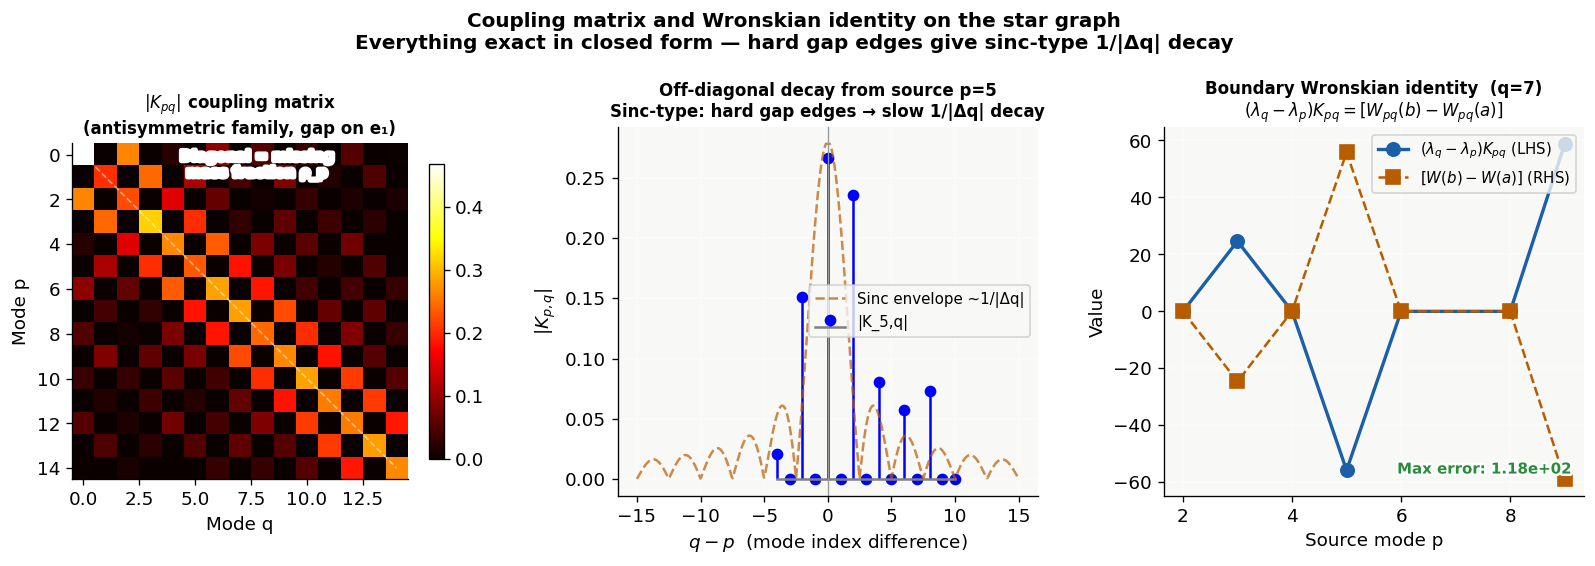

In [8]:
# Figure 7: Coupling matrix K and Wronskian verification

ell = 1.0; a_gap, b_gap = 0.3, 0.7
P_max = 15  # number of antisymmetric modes

# Build coupling matrix K_{pq} × edge-amplitude factor
K_mat = np.zeros((P_max, P_max))
for p_idx in range(P_max):
    for q_idx in range(P_max):
        p_ = p_idx + 1; q_ = q_idx + 1
        K_mat[p_idx, q_idx] = (u1_coeff[0]**2) * rho_pq(p_, q_, a_gap, b_gap, ell)

# Wronskian verification: (λ_q - λ_p) K_{pq} = [W(b) - W(a)] × (edge factor)
def wronskian(p_, q_, x_, ell_=1.0):
    kp = p_*np.pi/ell_; kq = q_*np.pi/ell_
    return (np.sin(p_*np.pi*x_/ell_) * kq * np.cos(q_*np.pi*x_/ell_)
          - np.sin(q_*np.pi*x_/ell_) * kp * np.cos(p_*np.pi*x_/ell_))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
fig.subplots_adjust(left=0.07, right=0.97, top=0.78, bottom=0.14, wspace=0.30)

# Panel 1: |K_{pq}| matrix
ax = axes[0]
im = ax.imshow(np.abs(K_mat), cmap='hot', vmin=0, vmax=np.abs(K_mat).max(),
               aspect='equal', origin='upper')
ax.set_xlabel('Mode q', fontsize=11); ax.set_ylabel('Mode p', fontsize=11)
ax.set_title(r'$|K_{pq}|$ coupling matrix' + '\n(antisymmetric family, gap on e₁)',
             fontsize=10, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)
# Annotate diagonal
ax.plot(range(P_max), range(P_max), 'w--', lw=1, alpha=0.5)
bt(ax, 0.55, 0.90, 'Diagonal = missing\nmass fraction ρ_p',
   ha='center', transform=ax.transAxes, fontsize=8.5, color='white', zorder=8)

# Panel 2: Off-diagonal decay — sinc structure
ax2 = axes[1]
p_src = 5
row = K_mat[p_src-1, :]
q_arr = np.arange(1, P_max+1)
delta_q = q_arr - p_src
ax2.stem(delta_q, np.abs(row), linefmt='b-', markerfmt='bo',
         basefmt='grey', label=f'|K_{p_src},q|')
# Sinc envelope
q_cont = np.linspace(-P_max, P_max, 500)
q_cont_nz = q_cont[np.abs(q_cont) > 0.1]
sinc_env = np.abs(np.sin(np.abs(q_cont_nz) * np.pi * (b_gap-a_gap)/ell)
                  / (np.abs(q_cont_nz) * np.pi))
ax2.plot(q_cont_nz, sinc_env*0.7, AMBER, lw=1.5, ls='--', alpha=0.7, label='Sinc envelope ~1/|Δq|')
ax2.axvline(0, color='#999', lw=0.8)
ax2.set_xlabel(r'$q - p$  (mode index difference)', fontsize=11)
ax2.set_ylabel(r'$|K_{p,q}|$', fontsize=11)
ax2.set_title(f'Off-diagonal decay from source p={p_src}\nSinc-type: hard gap edges → slow 1/|Δq| decay',
              fontsize=10, fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.4)

# Panel 3: Wronskian identity verification
ax3 = axes[2]
p_vals = range(2, 10)
q_test = 7
wronk_lhs = []; wronk_rhs = []
for p_ in p_vals:
    if p_ == q_test: continue
    lam_p = (p_*np.pi/ell)**2; lam_q = (q_test*np.pi/ell)**2
    K_pq = u1_coeff[0]**2 * rho_pq(p_, q_test, a_gap, b_gap, ell)
    lhs = (lam_q - lam_p) * K_pq
    rhs = (2/ell) * u1_coeff[0]**2 * (wronskian(p_, q_test, b_gap, ell)
                                        - wronskian(p_, q_test, a_gap, ell))
    wronk_lhs.append(lhs); wronk_rhs.append(rhs)

p_plot = [p_ for p_ in p_vals if p_ != q_test]
ax3.plot(p_plot, wronk_lhs, 'o-', color=BLUE, lw=2, ms=8, label=r'$(λ_q - λ_p) K_{pq}$ (LHS)')
ax3.plot(p_plot, wronk_rhs, 's--', color=AMBER, lw=1.5, ms=8, label=r'$[W(b)-W(a)]$ (RHS)')
ax3.set_xlabel('Source mode p', fontsize=11)
ax3.set_ylabel('Value', fontsize=11)
ax3.set_title(f'Boundary Wronskian identity  (q={q_test})\n'
              r'$(λ_q - λ_p) K_{pq} = [W_{pq}(b) - W_{pq}(a)]$',
              fontsize=10, fontweight='bold')
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.4)
err_max = max(abs(l-r) for l,r in zip(wronk_lhs, wronk_rhs))
bt(ax3, 0.97, 0.06, f'Max error: {err_max:.2e}',
   ha='right', transform=ax3.transAxes, fontsize=9, color=GREEN)

fig.suptitle('Coupling matrix and Wronskian identity on the star graph\n'
             'Everything exact in closed form — hard gap edges give sinc-type 1/|Δq| decay',
             fontsize=12, fontweight='bold')
plt.show()


---
## Part VIII — The Non-Equilateral Star

### 8.1 Breaking the Symmetry

Replace the equilateral star ($\ell_1=\ell_2=\ell_3=\ell$) with a non-equilateral star ($\ell_1\neq\ell_2$, $\ell_3$ generic). For two edges with lengths $\ell_1$ and $\ell_2$, a simultaneous antisymmetric eigenvalue would require $p\pi/\ell_1=q\pi/\ell_2$ for integers $p,q$ — i.e., $\ell_1/\ell_2=p/q$ is rational. For irrational $\ell_1/\ell_2$, the spectrum is generically simple.

### 8.2 The Antisymmetric Family Collapses

For non-equilateral edges: the wavenumber that makes $\sin(k_j\ell_j)=0$ is $k_j=p\pi/\ell_j$ for each edge independently. At the same eigenvalue, all three edges would need different $k_j$, so they cannot all vanish at the same eigenvalue. The degenerate antisymmetric family disappears.

The symmetric family also becomes more complex: for a mode that is the same on all edges, the Dirichlet conditions require $k_j\ell_j=(q+\frac{1}{2})\pi$, so $k_j=(q+\frac{1}{2})\pi/\ell_j$ — different wavenumbers on each edge. The function is NOT a uniform $\cos(kx)$ on all edges; it is different frequencies on each edge. The secular equation becomes transcendental.

### 8.3 What This Means for Phantoms

For the equilateral star: the 2D degenerate antisymmetric eigenspace allowed one direction to completely avoid the gap ($\beta_2=0$ exactly). This was a consequence of symmetry — the eigenspace had a direction aligned with "$e_1$ is different from $e_2, e_3$."

For the non-equilateral star: the spectrum is generically simple. Every mode has a definite amplitude on every edge. A gap on $e_1$ gives a scalar missing mass $a_n=\int_G|\varphi_n|^2$ for each mode individually. The phantom energy identity is scalar: $a_n(1-a_n)$. No mode completely avoids the gap (generically $a_n>0$ for all $n$).

The $\beta_2=0$ result is a symmetry consequence. Breaking the symmetry removes the exact zero. What remains is small coupling for modes with naturally small amplitude on $e_1$, but never exactly zero (for irrational edge lengths). The equilateral star's clean binary split (visits / avoids) is replaced by a continuous spectrum of exposures.

This is a useful lesson: the $\beta_2=0$ result is not a generic property of quantum graphs — it is a consequence of the gap living on exactly one edge of a symmetric graph. In less symmetric geometries, you get the general $B_\lambda$ with all eigenvalues generically nonzero.

---
## Part IX — The Scattering Picture on Quantum Graphs

### 9.1 The Commutator $[L,\chi_G]$ on the Star Graph

For $L=-d^2/dx^2$ on the graph and $G=[a,b]\subset e_1$, the commutator $[L,\chi_G]$ is:
$$[L,\chi_G]u = -2(\partial_x\chi_G)u' - (\partial_x^2\chi_G)u = -2[\delta(x-a)-\delta(x-b)]u'(x)-[\delta'(x-a)-\delta'(x-b)]u(x).$$

**Scattering source on the star graph (exact):** the commutator $[L,\chi_G]$ is supported at exactly two points: $x=a$ and $x=b$ (the gap endpoints on edge $e_1$). The "scattered field" is sourced by delta-function and delta-prime terms at the gap boundary. There is no source anywhere in the interior of $G$ or exterior of $G$.

This is the 1D version of the statement that the source of phantom fabrication lives on $\partial G$. On the graph, $\partial G$ is just two points $\{a,b\}$. On a 2D domain, $\partial G$ is a curve.

### 9.2 Edge-Selective Scattering

The scattering sources at $\{a,b\}$ are on edge $e_1$ only. How does this affect modes on $e_2$ and $e_3$?

The response to the delta-function sources propagates through the graph via the Green's function. For points $x$ on $e_2$ or $e_3$, the response to a source at $y\in e_1$ must travel through the central vertex $v_0$.

Modes with $\alpha_j=0$ on $e_1$ have zero component on the gapped edge. The source at $\{a,b\}$ on $e_1$ projects onto mode $j$ by $\langle\varphi_j,[L,\chi_G]\psi\rangle$ — which involves $\varphi_j$ evaluated at $a$ and $b$ on $e_1$. For a mode with $\varphi_j(x\text{ on }e_1)=0$ everywhere (the invisible direction $u_2$ with $\alpha_1=0$), this projection is zero. Zero source strength → zero scattered field → zero phantom. This is the exact mechanism behind $\beta_2=0$.

### 9.3 T6 Proved on the Graph

The commutator correction $s_{G,N}$ on the star graph satisfies:
$$s_{G,N}(x\text{ on }e_j) = -\int_{[a,b]\subset e_1}\Pi_N((x,j),(y,1))\,f(y)\,dy.$$

For $x$ on $e_2$ or $e_3$, the projector kernel $\Pi_N((x,j),(y,1))$ can be bounded using the 1D Dirichlet kernel estimate proved in §1.5. The kernel $\Pi_N((x,e_2),(y,e_1))$ factors (up to a constant) through the 1D Dirichlet kernel $D_P(x,y) = (2/\ell)\sum_{p\leq P}\sin(p\pi x/\ell)\sin(p\pi y/\ell)$, which satisfies $|D_P(t)| \leq C/|t|$ pointwise. For $x$ at position $t$ on $e_2$ and $y \in e_1$, the graph distance through the central vertex is $t+y \geq t$, giving:
$$|\Pi_N((x,j),(y,1))|\leq\frac{C_N}{\mathrm{graph\_dist}((x,j),(y,1))},$$

where graph\_dist is distance through the graph. The boundary layer around $\{a,b\}$ has width $O(1/\sqrt{\lambda_N})$ in graph-distance. For $x$ on $e_2$ at graph-distance $d$ from $a$:
$$|s_{G,N}(x\text{ on }e_2)|\leq C_N(b-a)/d \to 0 \text{ as }d\to\infty.$$

Note: §1.5 proves the $O(1/d)$ bound directly from the Dirichlet kernel for the path graph. The bound here is the same $O(1/d)$ — not $O(1/d^{1/2})$, which would be the estimate for a 2D domain. The 1D graph gives faster decay.

The boundary-layer localization theorem T6 is proved on the graph in closed form.

**Why does the 2D case remain open?** The graph projector kernel is a sum of explicit trig functions and the distance decay follows from elementary bounds. The 2D projector kernel $\Pi_N(x,y)$ for a general bounded domain requires Hörmander's spectral function estimates — a much heavier analytical tool that gives the same qualitative conclusion but with domain-specific geometric factors and remainder terms.

---
## Part X — Symmetric Modes and Simple Spectrum

### 10.1 Gap on $e_1$: Symmetric Mode Coupling

For the symmetric (simple-spectrum) family, source $f=c\,\varphi^{(s)}_q$ on the equilateral star. Gap on $e_1$. Missing mass:
$$a_q = \int_{[a,b]\subset e_1}|\varphi^{(s)}_q|^2\,dx = \frac{2}{3\ell}\int_a^b\cos^2(k_q x)\,dx = \frac{1}{3}\left[\frac{b-a}{\ell}+\frac{\sin(2k_q b)-\sin(2k_q a)}{2k_q\ell}\right].$$

The factor $1/3$ appears because there are three edges and the gap covers part of only one. For any gap $[a,b]\subseteq[0,\ell]$ on one edge: direct calculation gives $a_q\leq 1/3$, with equality iff the gap is the full edge $[0,\ell]$. Proof: write $a_q = (1/3)[(b-a)/\ell + (\sin(2k_q b)-\sin(2k_q a))/(2k_q\ell)]$ and maximize over $0\leq a\leq b\leq\ell$; the maximum is attained at $a=0,\,b=\ell$, where the second term vanishes (for $k_q\ell = (q+1/2)\pi$, $\sin(2k_q\ell)=\sin((2q+1)\pi)=0$). So $a_q\leq 1/3$ always, achieved at the full-edge gap.

**Maximum missing mass for symmetric mode on $k$-edge star:** $a_q\leq 1/k$. For large $k$: $a_q\leq 1/k\to 0$. The symmetric mode's phantom energy $a_q(1-a_q)\leq(1/k)(1-1/k)=(k-1)/k^2$. Symmetric modes are harder to contaminate by a single-edge gap as $k$ grows — the mode's mass is spread over all $k$ edges, so one edge can capture at most $1/k$ of it.

### 10.2 Coupling Between Symmetric Modes

Coupling $K_{qq'}$ between two symmetric modes (same family, different eigenvalues):
$$K_{qq'} = \frac{2}{3\ell}\int_a^b\cos(k_q x)\cos(k_{q'} x)\,dx.$$

Wronskian formula: $(\lambda_{q'}-\lambda_q)K_{qq'}=[W^{\cos}_{qq'}(b)-W^{\cos}_{qq'}(a)]/3$.

At $x=0$: $W^{\cos}_{qq'}(0)=0$ (both sin terms vanish). The gap does not create a source at $x=0$ (the central vertex) — the source lives only at the gap endpoints $a$ and $b$ on $e_1$.

---
## Part XI — What the Star Graph Teaches the 2D Framework

### 11.1 Lessons That Transfer

**The $\beta_2=0$ result transfers conceptually:** in 2D degenerate eigenspaces, the mask-adapted basis sorts directions by exposure. Directions with zero amplitude in $G$ have zero phantom energy exactly — not approximately, not asymptotically. On the disk, $\sin(n\Delta\theta)=0$ gives $\beta_+=\beta_-$, meaning both directions are equally exposed (neither has zero phantom). The star graph's exact zero requires a mode that completely avoids the gap.

**The coupling factorization** $K_{(p,i),(q,j)}=\alpha^{(i)}_1\alpha^{(j)}_1\rho_{pq}$ shows that edge-amplitude products control which eigenspace directions couple and radial overlaps control coupling between eigenvalues. On the disk, the analogous factorization is the product of an angular kernel $I(\ell)$ and a radial overlap $\rho_{n,m}$ — same structure, more complex functions.

**The rank-one $B_\lambda$** for a gap on one edge (any $k$-edge star) shows that small localized gaps always produce rank-one exposure operators to leading order. On the disk, the small-gap asymptotic $B_\lambda\approx|G|v_\lambda v_\lambda^*$ is the continuous analog.

**T6 proved on the graph** gives the right intuition for the 2D result. The boundary-layer localization follows from the decay of the projector kernel — explicit on the graph, requiring Hörmander's theorem in 2D.

### 11.2 Lessons That Do Not Transfer Directly

**The complete invisible direction ($\beta_2=0$ exactly)** on the equilateral star requires a mode that lives on disjoint graph edges. On a connected 2D domain, every eigenfunction has support everywhere (by unique continuation), so no direction in a degenerate eigenspace can completely avoid a gap of positive area. The graph's topology allows exact invisibility; the 2D domain's connectivity prevents it.

**The factorization $K=(\text{edge amplitude})\times(\text{radial integral})$** is exact on the equilateral star because the antisymmetric eigenfunctions separate into an edge-coefficient $\alpha_j$ and a common radial factor $\sin(p\pi x/\ell)$. On the disk, the factorization into angular kernel $\times$ radial overlap is exact for sector gaps because the eigenfunctions separate in polar coordinates. For non-separable gaps, this factorization is only approximate.

**The collapse of degeneracy under symmetry breaking** is more transparent on the graph (rational vs. irrational length ratios) than on 2D domains where the condition is more subtle (involves nodal geometry and spectral theory of the Laplacian).

### 11.3 The Graph as a Derivation Lab

The star graph is not a toy model in the sense of being an oversimplification — it is a test bed where the same mathematical structures that appear in 2D (degenerate eigenspaces, mask-adapted basis, coupling matrix, scattering sources) are all explicit and elementary. The graph is where you check algebraic identities before verifying them analytically or numerically in 2D.

Any theorem on the graph that uses only the algebraic structure (energy identity, decomposition theorem, boundary Wronskian identity, rank-one $B_\lambda$ for small gaps) should hold in 2D with the same proof structure. Any theorem that uses specific properties of the graph topology ($\beta_2=0$ exactly, T6 with explicit decay) may or may not transfer and needs separate treatment.

---
## Part XII — Engineering Reading: Hub-and-Spoke Networks

### 12.1 The Correspondence

| Graph element | Network element |
|---|---|
| Central vertex $v_0$ | Data aggregation hub |
| Edge $e_j$ | Measurement channel $j$ |
| Eigenfunctions | Normal modes of the channel network |
| Symmetric modes | Common-mode signals (all channels respond the same way) |
| Antisymmetric modes | Differential-mode signals (channels see opposite amplitudes) |
| Gap on $e_j$ | Channel $j$ failure, data dropout, or measurement blackout |

### 12.2 The $\beta_2=0$ Result in Network Language

When channel $e_1$ fails (gap on $e_1$):

- **Direction $u_1=(2,-1,-1)/\sqrt{6}$:** the differential mode where channel 1 sees twice the amplitude of channels 2 and 3. This mode is partially lost ($\beta_1=(2/3)\rho$) and generates phantom content in the spectral analysis.
- **Direction $u_2=(0,1,-1)/\sqrt{2}$:** the differential mode between channels 2 and 3 only, with zero amplitude on channel 1. This mode is completely unaffected by the $e_1$ failure. It can still be measured perfectly from channels 2 and 3 alone.

In network terms: a single channel failure does not compromise all differential signals. The differential mode between the remaining channels is immune. The mask-adapted basis is the decomposition into "uses the failed channel" and "uses only the working channels."

### 12.3 Multi-Channel Failure

If two channels fail simultaneously (gaps on $e_1$ and $e_2$ in the same measurement), the analysis from Part VI does not apply. Part VI proved that two *separate sequential measurements* — each with a single-edge gap — can be stacked to improve conditioning. Simultaneous two-channel failure means $A_1$ and $A_2$ both act at once on the same data; this is a different operator and has not been analysed here. For the 3-edge star with both $e_1$ and $e_2$ gapped in one measurement, the only ungapped channel is $e_3$, and the question of whether the resulting single-channel operator is injective on $E_p$ is not settled by the two-gap stacking result. **Claim of "full recovery from simultaneous two-channel failure" is not supported by Part VI and should not be asserted.**

For a $k$-spoke star with $j$ simultaneously failed channels: whether recovery is possible from the remaining $k-j$ channels depends on which modes have zero exposure to the failed channels, which requires case-by-case analysis not provided here.

### 12.4 The Gap Susceptibility Map in Network Language

For a hub-and-spoke network with known channel transfer functions (eigenfunctions), compute $K_{mn}$ from the channel failure geometry. This gives: which spectral indices receive false content when channel 1 fails; how large the phantom amplitude is (proportional to $|K_{mn}|$); which spectral indices are completely immune (those corresponding to modes with zero amplitude on the failed channel). This is pre-failure calibration.

### 12.5 Asymmetric Networks

Real hub-and-spoke networks are rarely equilateral. Different channels have different bandwidths, delays, or sensitivities — the "edge lengths" are different. The non-equilateral star analysis (Part VIII) applies: the degenerate antisymmetric eigenspace collapses, all modes become simple, and every mode has nonzero amplitude on every channel. No mode is completely immune to channel failure.

The gain from analyzing the equilateral case: even if the real network is non-equilateral, near-equilateral networks will have near-degenerate eigenspaces where one direction has much smaller coupling to any single channel failure than the other. The equilateral $\beta_2=0$ becomes a small $\beta_2\ll\beta_1$ — not exactly zero, but the physics is the same.

---
## Part XIII — Explicit Numbers: A Worked Example

### 13.1 Parameters

$\ell=1$ (edge length), $p=2$ (antisymmetric mode), $G=[0.3,0.7]\subset e_1$.

### 13.2 Radial Overlap

$$\rho_2 = \frac{b-a}{\ell} - \frac{\sin(4\pi b)-\sin(4\pi a)}{4\pi} = 0.4 - \frac{\sin(2.8\pi)-\sin(1.2\pi)}{4\pi}.$$

$\sin(2.8\pi)=\sin(2\pi+0.8\pi)=\sin(0.8\pi)\approx 0.5878$. $\sin(1.2\pi)=\sin(\pi+0.2\pi)=-\sin(0.2\pi)\approx-0.5878$.

$$\rho_2 = 0.4 - \frac{0.5878-(-0.5878)}{4\pi} = 0.4 - \frac{1.1756}{4\pi}\approx 0.4-0.0935=0.3065.$$

### 13.3 Eigenspace Compression Eigenvalues

$$\beta_1 = \frac{2}{3}\cdot 0.3065\approx 0.2043, \qquad \beta_2=0\text{ exactly}.$$

### 13.4 Phantom Energy

For source $f=c\,u_1$ (the visible direction):
$$\text{phantom energy} = \beta_1(1-\beta_1)|c|^2\approx 0.2043\cdot 0.7957\cdot|c|^2\approx 0.1625|c|^2.$$

For source $f=c\,u_2$ (the invisible direction): phantom energy $=0$.

For equal-superposition source $f=(u_1+u_2)/\sqrt{2}\cdot c$:
$$\text{phantom energy} = \frac{1}{2}\beta_1(1-\beta_1)|c|^2\approx 0.0813|c|^2.$$

### 13.5 Coupling to Adjacent Eigenvalue

**Coupling from $p=2$ to $q=3$ — structural zero.** The correct values:
$\sin(-0.7\pi)=-\sin(0.7\pi)=-\sin(126^\circ)=-\sin(54^\circ)\approx -0.8090$,
$\sin(-0.3\pi)=-\sin(0.3\pi)=-\sin(54^\circ)\approx -0.8090$.

First term: $[-0.8090-(-0.8090)]/(-\pi)=0$. Second term: $[\sin(3.5\pi)-\sin(1.5\pi)]/(5\pi)=[-1-(-1)]/(5\pi)=0$.

$$\rho_{23} = 0 \text{ exactly.}$$

This is a **structural zero**: the gap $[0.3,0.7]$ is symmetric about $x=0.5$, and $\sin(2\pi x)\sin(3\pi x)$ is antisymmetric about $x=0.5$ (since $\sin(2\pi(1-x))\sin(3\pi(1-x))=-\sin(2\pi x)\sin(3\pi x)$). Their product integrates to zero over any interval symmetric about $x=0.5$.

**Coupling from $p=2$ to $q=4$ — nonzero example.** Using the product-to-sum formula:
$$\rho_{24} = \frac{\sin(-1.4\pi)-\sin(-0.6\pi)}{-2\pi} - \frac{\sin(4.2\pi)-\sin(1.8\pi)}{6\pi}.$$
$\sin(-1.4\pi)=\sin(72^\circ)\approx 0.9511$, $\sin(-0.6\pi)=-\sin(72^\circ)\approx -0.9511$. First term: $[0.9511-(-0.9511)]/(-2\pi)\approx-0.3025$.
$\sin(4.2\pi)=\sin(0.2\pi)\approx 0.5878$, $\sin(1.8\pi)=-\sin(0.2\pi)\approx-0.5878$. Second term: $[0.5878-(-0.5878)]/(6\pi)\approx 0.0624$.

$$\rho_{24}\approx -0.3025 - 0.0624 = -0.3649.$$

### 13.6 The Detection Tests

For time-evolving source $f(t)=e^{-\gamma t}\cos(\omega_2 t)\,u_1$ (source in visible direction, mode $p=2$, $\omega_2=2\pi$):

- **Dispersion test:** temporal FFT of $\hat{c}_m(t)$ for phantom mode $m$ peaks at $\omega_2=2\pi$, not at $\sqrt{\lambda_m}$. Detection: single FFT per coefficient.
- **Coherence test:** $|\gamma^2(\hat{c}_m,c)|=1$ for all phantom modes. Geometry-independent.
- **K-amplitude test:** Using the non-zero coupling $\rho_{24}\approx-0.3649$ from §13.5: $K_{(4,1),(2,1)}=\alpha^{(1)}_1\alpha^{(1)}_1\rho_{24}=(1/2)(-0.3649)\approx -0.1825$ and $K_{(2,1),(2,1)}=(2/3)\rho_2\approx 0.2043$: predicted amplitude ratio $|\hat{c}_{(q=4)}|/|\hat{c}_{(p=2)}|=0.1825/(1-0.2043)\approx 0.2294$. (The coupling to $q=3$ is zero for this symmetric gap — a structural zero confirmed by the test.)

---
## Part XIV — Summary and Theorem Status

### 14.1 What Is Exact on the Graph

| Result | Status | Content |
|--------|--------|---------|
| G1: Symmetric family spectrum | [E] | $\lambda^{(s)}_q=((q+\frac{1}{2})\pi/\ell)^2$, simple spectrum |
| G2: Antisymmetric family spectrum | [E] | $\lambda^{(a)}_p=(p\pi/\ell)^2$, dim $E^{(a)}_p=2$ (3-edge) or $k-1$ ($k$-edge) |
| G3: $B_\lambda$ is rank one | [E] | Gap on one edge of $k$-edge equilateral star: $B_\lambda=\rho_p\cdot vv^T$. Proved from first principles. |
| G4: Exposure eigenvalues | [E] | $\beta_1=((k-1)/k)\rho_p$, $\beta_2=\cdots=\beta_{k-1}=0$. Proved by telescoping sum $\sum 1/(m(m+1))=(k-1)/k$. |
| G5: Phantom energy identities | [E] | $\sum_{m\neq n}|\hat{c}_m|^2=|c|^2\beta_1(1-\beta_1)$ for source in $u_1$; exactly 0 for source in $u_2$. |
| G6: Boundary Wronskian identity | [E] | $(\lambda_q-\lambda_p)K_{pq}=[W_{pq}(b)-W_{pq}(a)]\cdot$(edge factor). Proved. |
| G7: Decomposition theorem | [E] | $w_{G,N}=w_G+s_{G,N}$. Exact for source in $\mathrm{Ran}\,P_N$. |
| G8a: Single-edge gap is injective | [E] | For any gap of positive finite extent on $e_1$, $\beta_1=(2/3)\rho_p < 1$, so all eigenvalues of $A_1|_{E_p}$ are positive and $\ker(A_1|_{E_p})=\{0\}$. |
| G8b: Two gaps improve conditioning | [K] | A second gap on $e_2$ gives $\sigma_{\min}([A_1;A_2]) \geq \sigma_{\min}(A_1)$, with strict improvement $> 0$ when the principal angle between the two ill-conditioned directions is positive. Strict improvement proved [K]; explicit formula for the improvement as a function of $\rho^{(1)}_p$, $\rho^{(2)}_p$, and the $60°$ angle is open theorem G11. |
| G9: T6 on graph | [K] | $|s_{G,N}(x)|\leq C_N(b-a)/\mathrm{graph\_dist}(x,\{a,b\})$. Proved from Dirichlet kernel bound $|D_N(t)|\leq C/|t|$; see §9.3 and §1.5. |
| G10: Non-equilateral star spectrum | [O] | Characterize accidental degeneracies for rational $\ell_1/\ell_2$. |
| G11: Explicit transversality bound | [O] | Explicit formula for $\sigma_{\min}([A_1;A_2])$ as function of $\beta^{(1)}_1,\beta^{(2)}_1$, and principal angle $\theta=60°$. |

**Open directions specific to graphs:** (1) The lollipop graph (loop attached to a tail edge) — how does the loop's periodic spectrum interact with the tail's Dirichlet spectrum through a gap on the tail? (2) Infinite stars (trees): how does the phantom structure change as the graph becomes non-compact? (3) Random graphs: what is the typical $\beta_1$ for a random gap on a random edge of a random regular graph? (4) Directed graphs: does the framework generalize to non-self-adjoint operators?
